# Live2026 forecast — cached downloads and fresh inference

**Run All checks source freshness every time.** Public sources are downloaded when the successful-check cache is older than six hours; FORCE=True bypasses that cache. Changed sources trigger cleanup/alignment and new predictions. All outputs are timestamped.

Failed providers use verified cached data with explicit stale status. STRICT=True fails instead. OFFLINE=True deliberately disables downloads. The table below distinguishes checks from the dates of actual observations. Do not describe a cached feature as newly observed.

The2026 model checkpoint, historical fits and normalizers stay fixed. New polls and feature values update its inference. Political control after its September17 review is explicitly carried forward as a scenario assumption. Candidate changes remain subject to the reviewed screening policy.

In [1]:
from pathlib import Path
import sys, json, importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0, str(ROOT))
import election_lab as lab
import model_portfolio
# Refresh inference and display helpers when Run All uses an existing kernel.
importlib.reload(lab)
importlib.reload(model_portfolio)
import model_labels
importlib.reload(model_labels)
from model_labels import display, model_label, MODEL_GUIDE
pd.set_option('display.max_rows', 40)

FORCE = False
OFFLINE = False
STRICT = False
INCLUDE_STUDENT = True
TTL_HOURS = 6
TIMEOUT_SECONDS = 15
import importlib
import live_share_images

# Polling-coverage rules used consistently by charts and watchlists.
RECENT_DAYS = 30
MIN_95_WIDTH_PP = 25.0
MIN_RECENT_SAMPLES = 3
MIN_RECENT_FIRMS = 2

# Reload ingestion fixes when reusing a live kernel.
import current_poll_review, prepare_data, normalize_data, compact_data
for module in [current_poll_review, prepare_data, normalize_data, compact_data]:
    importlib.reload(module)


## 1. Download/check, prepare and predict

This is the entire supported data-to-model handoff. Verbose download/preparation output is saved to the run log. A failed preparation preserves the last successful forecast.

In [2]:
RUN=lab.run_logged(lab.refresh,force=FORCE,offline=OFFLINE,strict=STRICT,ttl_hours=TTL_HOURS,timeout=TIMEOUT_SECONDS,include_student=INCLUDE_STUDENT)
meta=json.loads((RUN/'run.json').read_text())
print('Forecast:',RUN.relative_to(ROOT),'| Cutoff:',meta['as_of'])
print('Training through:',meta['trained_through'],'| Political review:',meta['political_reference_reviewed_through'],'| Carried forward:',meta['political_context_carried_forward'])
SHARE_DIR = ROOT/'cache/share_images'/RUN.name


Run log: cache/logs/refresh_20260925T165445.088654Z.txt
Forecast: cache/runs/live/20260925T165454.221722Z | Cutoff: 2026-09-25
Training through: 2024 | Political review: 2026-09-17 | Carried forward: True


## 2. Freshness and screened evidence

A successful online check can find unchanged data. Stale-cache status is a download failure, not a fresh observation. Current labels remain missing; poll/sample exclusions remain visible.

In [3]:
from IPython.display import HTML
from source_status import format_source_status

fresh = format_source_status(meta['freshness']['sources'])
display(HTML(fresh.to_html(index=False, escape=True)))
audit = pd.read_parquet(RUN/'poll_audit.parquet')
display(audit.baseline_status.value_counts().rename('answer_or_question_versions'))
display(pd.read_parquet(RUN/'feature_scores.parquet').round(3))
print('Missing score fields:', meta['missing_current_feature_scores'])


source,acquisition_status,checked_at,poll_latest_dates,failure_type,failure_detail
polls,fresh_check_cache,2026-09-25T16:00:45.044540+00:00,generic_latest_poll_end: 2026-09-22; latest_poll_end: 2026-09-24,None,
fred,fresh_check_cache,2026-09-25T16:00:45.904634+00:00,None,None,
michigan,fresh_check_cache,2026-09-25T16:00:46.960671+00:00,None,None,
ucsb,fresh_check_cache,2026-09-25T16:00:42.728027+00:00,None,None,
french,fresh_check_cache,2026-09-25T16:00:44.163764+00:00,None,None,
cboe,fresh_check_cache,2026-09-25T16:00:45.897772+00:00,None,None,
gpr,fresh_check_cache,2026-09-25T16:00:47.829208+00:00,None,None,
epu,fresh_check_cache,2026-09-25T16:00:48.489066+00:00,None,None,
infectious_emv,fresh_check_cache,2026-09-25T16:00:47.810410+00:00,None,None,


baseline_status
eligible                           903
source_or_matchup_restriction      325
alternative_population_or_basis     23
before_two_year_cycle                4
Name: answer_or_question_versions, dtype: int64

,cycle,scenario,context_id,start_cutoff,previous_cutoff,desired_cutoff,window_complete,wh_sign,economy_conditions,economy_momentum,...,conditions_required,momentum_known,momentum_required,normalization_cycles,normalization_first_cycle,normalization_last_cycle,calendar_status,economy_conditions_missing_components,economy_momentum_missing_components,model_inputs_complete
0,2026,matched_live,2026-09-25,2026-01-01,2025-10-31,2026-10-31,False,-1,-0.78,-0.436,...,5,10,10,24,1978,2024,available_at_cutoff,,,True


Missing score fields: []


## All-state polling audit
Independent candidates retain their IND affiliation. The table audits every Senate state, including those without polls.

In [4]:
from live_poll_audit import build_poll_audit, METHOD as POLL_SIDE_METHOD
poll_coverage = build_poll_audit(RUN)
print(POLL_SIDE_METHOD)
display(HTML(poll_coverage['summary'].to_html(index=False, escape=True)))
print('Reasons for excluded questions:')
display(HTML(poll_coverage['reasons'].to_html(index=False, escape=True)))
print("All-state integrity checks:")
display(HTML(poll_coverage["checks"].to_html(index=False, escape=True)))
print("Reviewed qualifications (partial ballots, aliases, date bounds):")
display(HTML(poll_coverage["flags"].to_html(index=False, escape=True)))


D/Independent is the forecast side, not a party label. Independent candidates remain IND. For questions with multiple D/IND candidates, the input is the strongest individual candidate minus the Republican, never their combined votes. This is a scalar proxy, not a joint candidate-level win model. Independent winners count on the D/Independent chamber side by modeling assumption, not a verified caucus commitment. Reviewed supplements and exact candidate aliases are applied automatically. Conditional/reduced-ballot versions are kept separately from the preferred ballot. Partial ballots and inferred date bounds remain explicitly flagged. All source questions are retained in the audit. Obsolete matchups, incompatible questions, duplicate sample versions and observations unavailable at the cutoff do not contribute.


State,Questions,Eligible,Excluded,Independent candidates in eligible polls
AK,28,14,14,None
AL,1,1,0,None
AR,4,4,0,None
CO,0,0,0,None
DE,0,0,0,None
FL,25,9,16,None
GA,50,16,34,Allen Buckley
IA,33,20,13,None
ID,12,6,6,"Natalie Fleming, Todd Achilles"
IL,0,0,0,None


Reasons for excluded questions:


State,Reason,Questions
AK,D_IND_vs_REP|independent_candidate_present|rcv_round_1|strongest_opponent_proxy|unreviewed_or_former_contender,1
AK,before_two_year_cycle,1
AK,conditional_missing_ballot_contender|missing_reviewed_contender|unreviewed_or_former_contender,2
AK,rcv_round_1|strongest_opponent_proxy|unreviewed_or_former_contender,1
AK,rcv_round_1|unreviewed_or_former_contender,6
AK,rcv_round_2|unreviewed_or_former_contender,1
AK,unreviewed_or_former_contender,2
FL,conditional_missing_ballot_contender|missing_reviewed_contender|unreviewed_or_former_contender,16
GA,alternative_population_or_basis,3
GA,conditional_missing_ballot_contender|missing_reviewed_contender|unreviewed_or_former_contender,30


All-state integrity checks:


Check,Passed
Every source question has a forecast disposition,True
All admitted questions have valid margins and sample sizes,True
No rejected ballot/scenario enters the forecast,True
No admitted fieldwork or known release is after cutoff,True


Reviewed qualifications (partial ballots, aliases, date bounds):


geography,pollster,poll_end,quality_flags
LA,Public Policy Polling,2026-07-22,reviewed_candidate_alias
ID,The Bullfinch Group,2026-06-01,D_IND_vs_REP|independent_candidate_present|partial_ballot_coverage
ID,Change Research,2026-07-30,D_IND_vs_REP|independent_candidate_present|reviewed_missing_sample_size|strongest_opponent_proxy
ID,Public Policy Polling,2026-03-17,D_IND_vs_REP|independent_candidate_present|partial_ballot_coverage
ID,The Bullfinch Group,2026-08-07,D_IND_vs_REP|independent_candidate_present|partial_ballot_coverage
ID,Advanced Targeting Research,2026-09-16,D_IND_vs_REP|independent_candidate_present|partial_ballot_coverage
VA,The Public Sentiment Institute,2026-06-16,D_IND_vs_REP|independent_candidate_present|publication_date_upper_bound|strongest_opponent_proxy


## 3. Full chamber forecast

The final Gaussian is the reference. Both Student versions and the older Gaussian are alternatives, all updated with the same evidence. The fixed25%-each mixture represents model uncertainty. Its20% polling adjustment translates means only; it preserves mixture covariance. Older Gaussian-only polling blends remain in saved data.

Point totals count positive means; expected totals sum win probabilities. D control requires51 seats. The non-Bayesian helper alone uses independent-state chamber uncertainty. These are exploratory alternatives, not independently validated winners.

All forecasts shown here use polling evidence when available. The empirical baseline uses poll averages and historical polling-error patterns. A 20% shift moves the predicted margin one-fifth of the way toward that baseline while retaining the original model’s uncertainty distribution. It does not mean the other models omit polls or need correction.

,model,point_D,point_R,expected_D,D control %,D_lo70,D_hi70
0,Gaussian Bayesian,51,49,50.891,60.173,49,52
1,Matched Student-t (df5),51,49,51.008,63.500,50,52
2,Older Gaussian,51,49,51.824,75.123,50,54
3,Student-t research helper,51,49,51.799,76.500,50,54
4,Empirical baseline,48,52,49.481,32.368,47,52
5,Four-model mixture,51,49,51.376,68.824,50,53
6,Mixture: 20% shift toward baseline,51,49,51.015,60.878,49,53


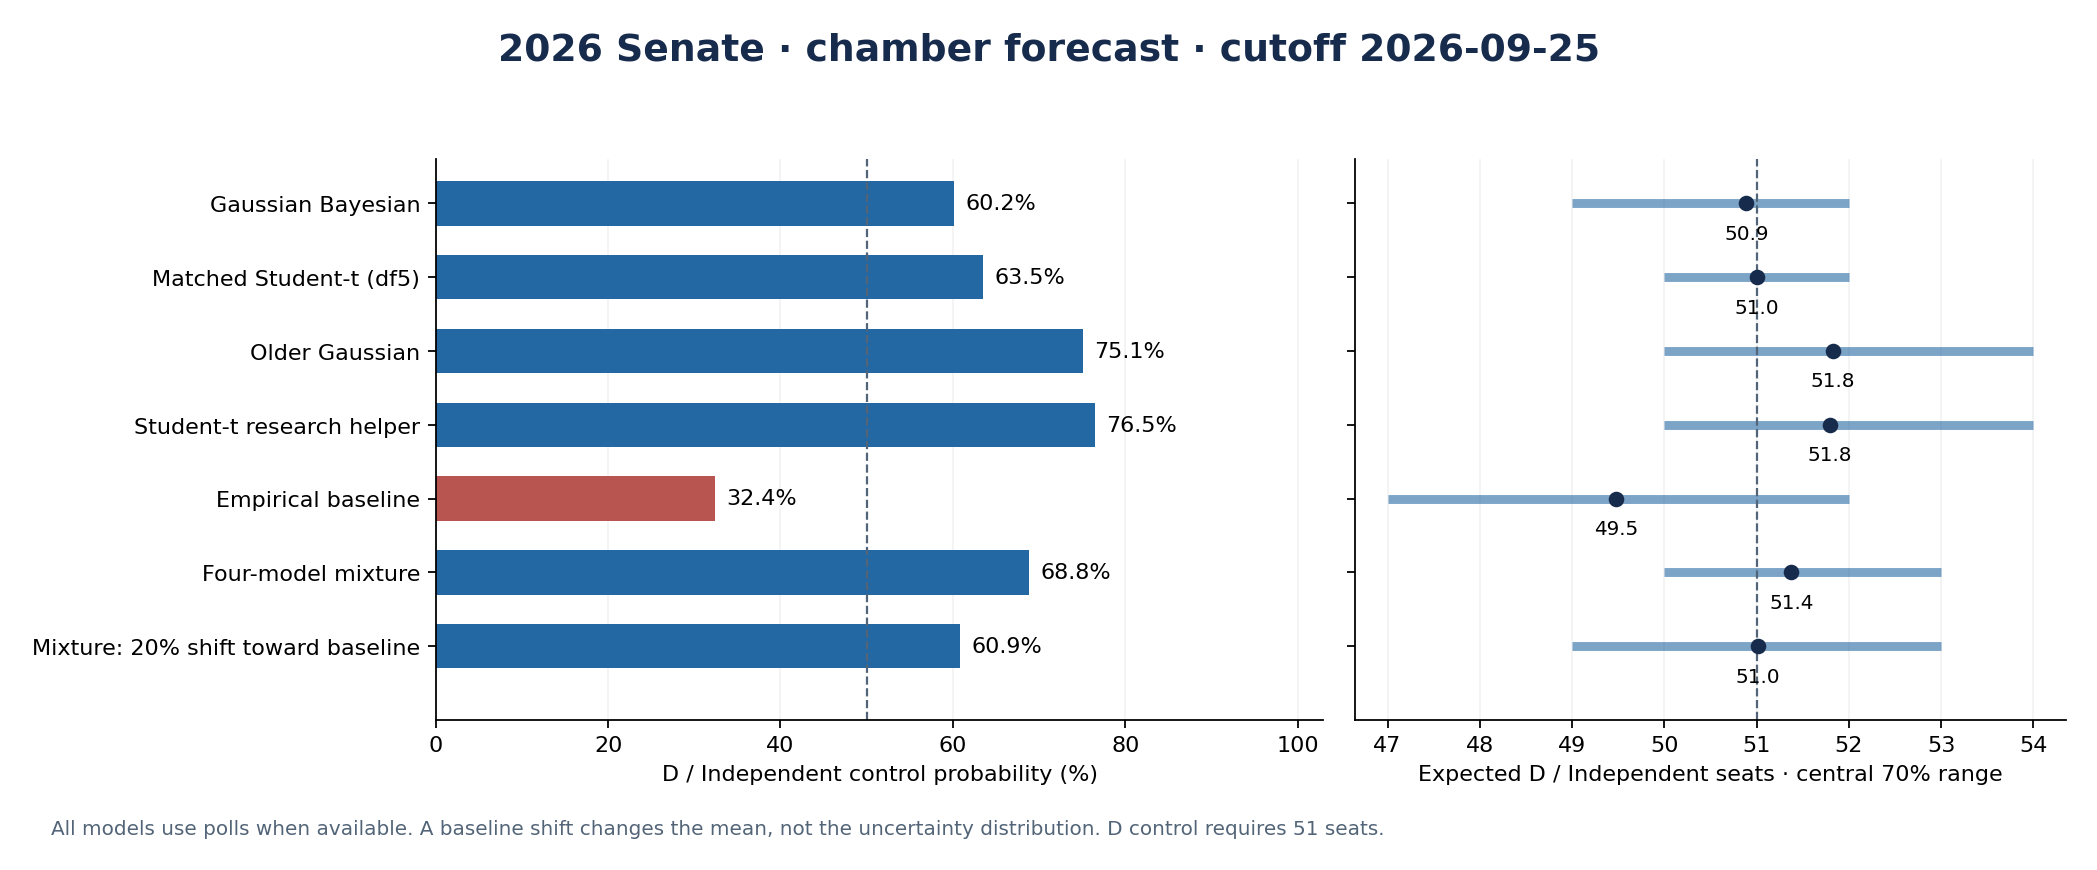

In [5]:
# Reload chart styling even when this cell runs in an existing kernel.
import importlib, live_share_images
importlib.reload(live_share_images)

from IPython.display import Markdown
display(Markdown(MODEL_GUIDE))
tables=lab.display_tables(RUN)
DISPLAY_MODELS=['Bayesian','Matched Student-t (df5)','Older Gaussian','Student-t research helper','Non-Bayesian corrected','Four-model mixture','Mixture + polling 20%']
seats=tables['seats'].set_index('model').reindex([m for m in DISPLAY_MODELS if m in tables['seats'].model.values]).reset_index()
seats['D control %']=100*seats.p_D_control
display(seats[['model','point_D','point_R','expected_D','D control %','D_lo70','D_hi70']].round(3))
live_share_images.display_images(live_share_images.chamber_images(seats, SHARE_DIR, meta['as_of']))


## 4. State margins and probabilities

Positive D−R margins favor Democrats. Unpolled states remain in the model; their estimates rely on priors and cross-state information. Blend percentages are sensitivities, not a selected new main forecast.

The margin chart shows the four-model mixture mean, its central 68% (thick) and 95% (thin) predictive intervals, and a separate panel of average pairwise margin disagreement among its four components. The probability chart shows mixture win probabilities. Row guides align each race across panels.


D/Independent−R margins (pp)


model,Gaussian Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Empirical baseline,Four-model mixture,Mixture: 20% shift toward baseline
State,,,,,,,
AK,-2.46,-2.40,-0.43,-0.48,-2.04,-1.44,-1.56
AL,-21.27,-21.25,-17.92,-18.20,-21.69,-19.66,-20.07
AR,-19.97,-18.96,-11.66,-11.31,-23.32,-15.48,-17.05
CO,18.56,18.76,15.23,15.58,5.95,17.03,14.82
DE,26.08,26.28,26.71,27.06,15.52,26.53,24.33
FL (special),-5.88,-5.79,-5.85,-5.77,-11.21,-5.82,-6.90
GA,6.66,6.71,7.52,7.52,5.03,7.10,6.69
IA,-2.10,-2.04,-1.61,-1.59,-4.26,-1.84,-2.32
ID,-17.71,-16.85,-17.18,-15.83,-7.53,-16.89,-15.02


D/Independent win probabilities (%)


model,Gaussian Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Empirical baseline,Four-model mixture,Mixture: 20% shift toward baseline
State,,,,,,,
AK,33.9,30.9,47.7,46.8,43.5,40.0,39.2
AL,0.1,0.2,3.8,2.2,4.2,1.5,1.4
AR,0.2,0.8,15.2,10.1,3.1,6.6,5.1
CO,94.0,95.1,87.4,90.5,68.2,91.7,88.9
DE,100.0,99.6,99.5,99.1,89.2,99.6,99.3
FL (special),18.5,13.4,25.2,18.8,18.6,18.9,15.0
GA,87.3,91.9,84.8,90.6,65.6,88.6,87.2
IA,36.2,33.7,40.6,38.0,36.7,36.9,33.7
ID,0.1,0.3,0.2,0.5,27.4,0.2,0.6


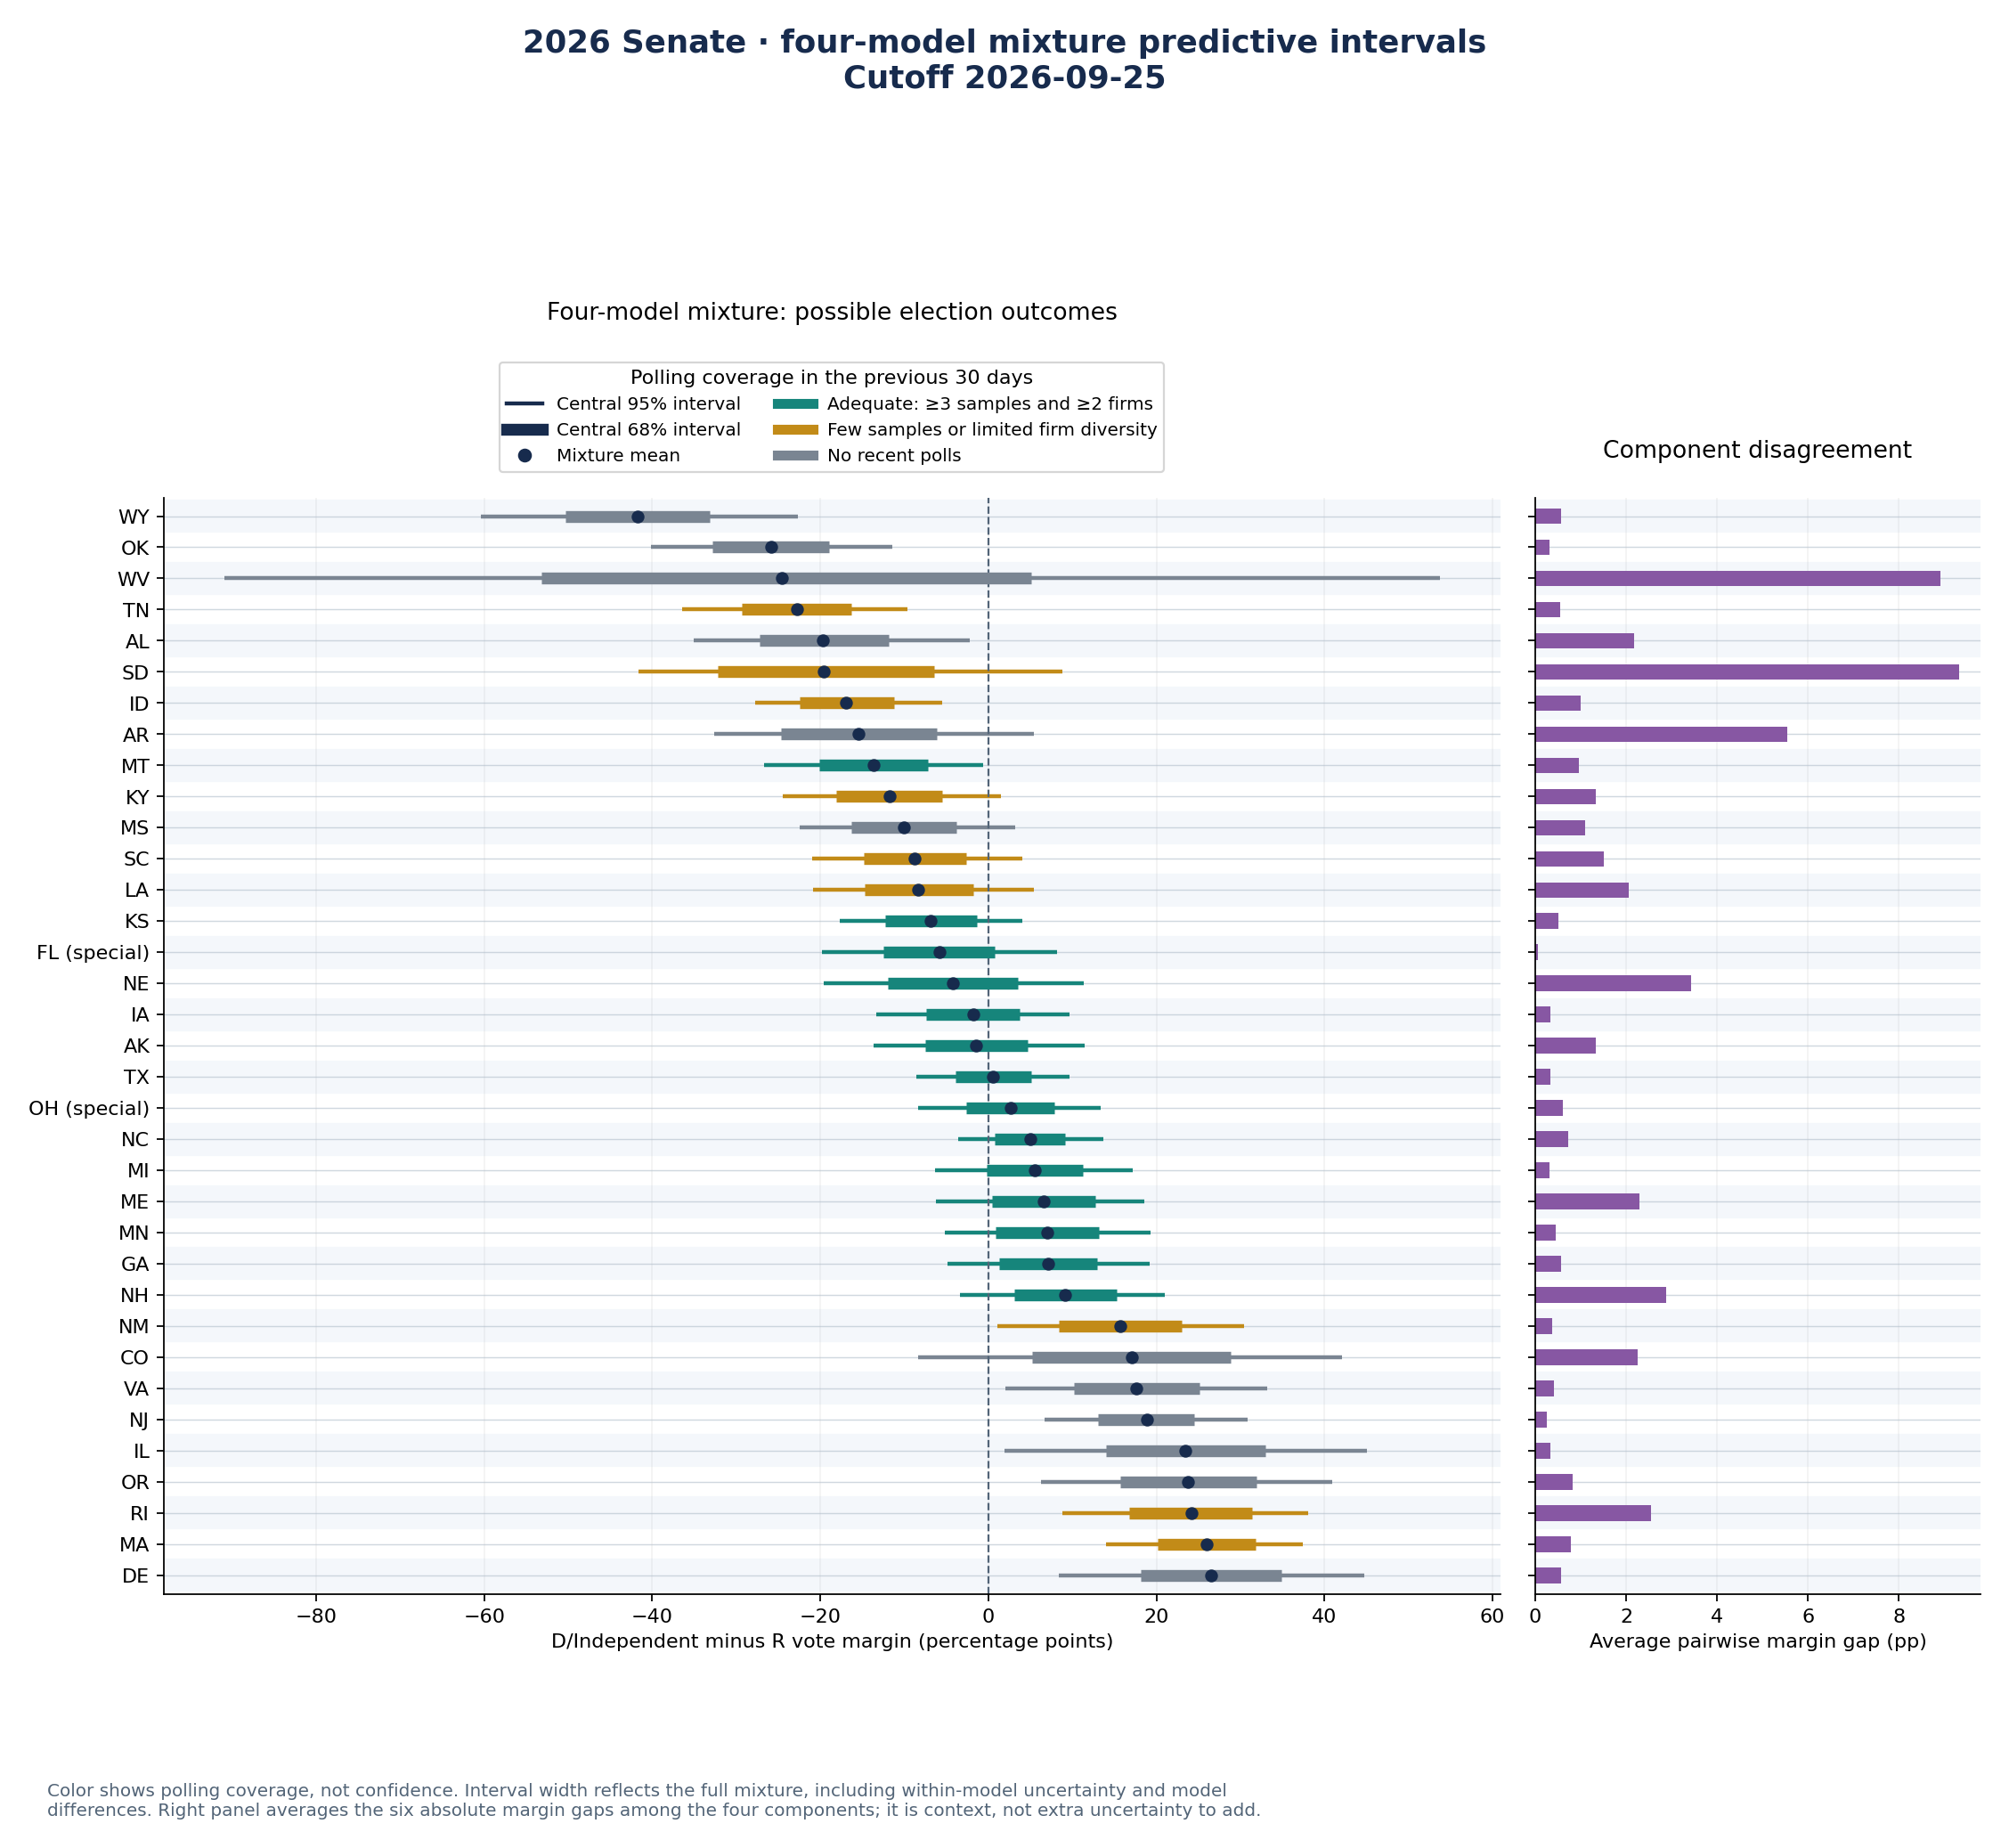

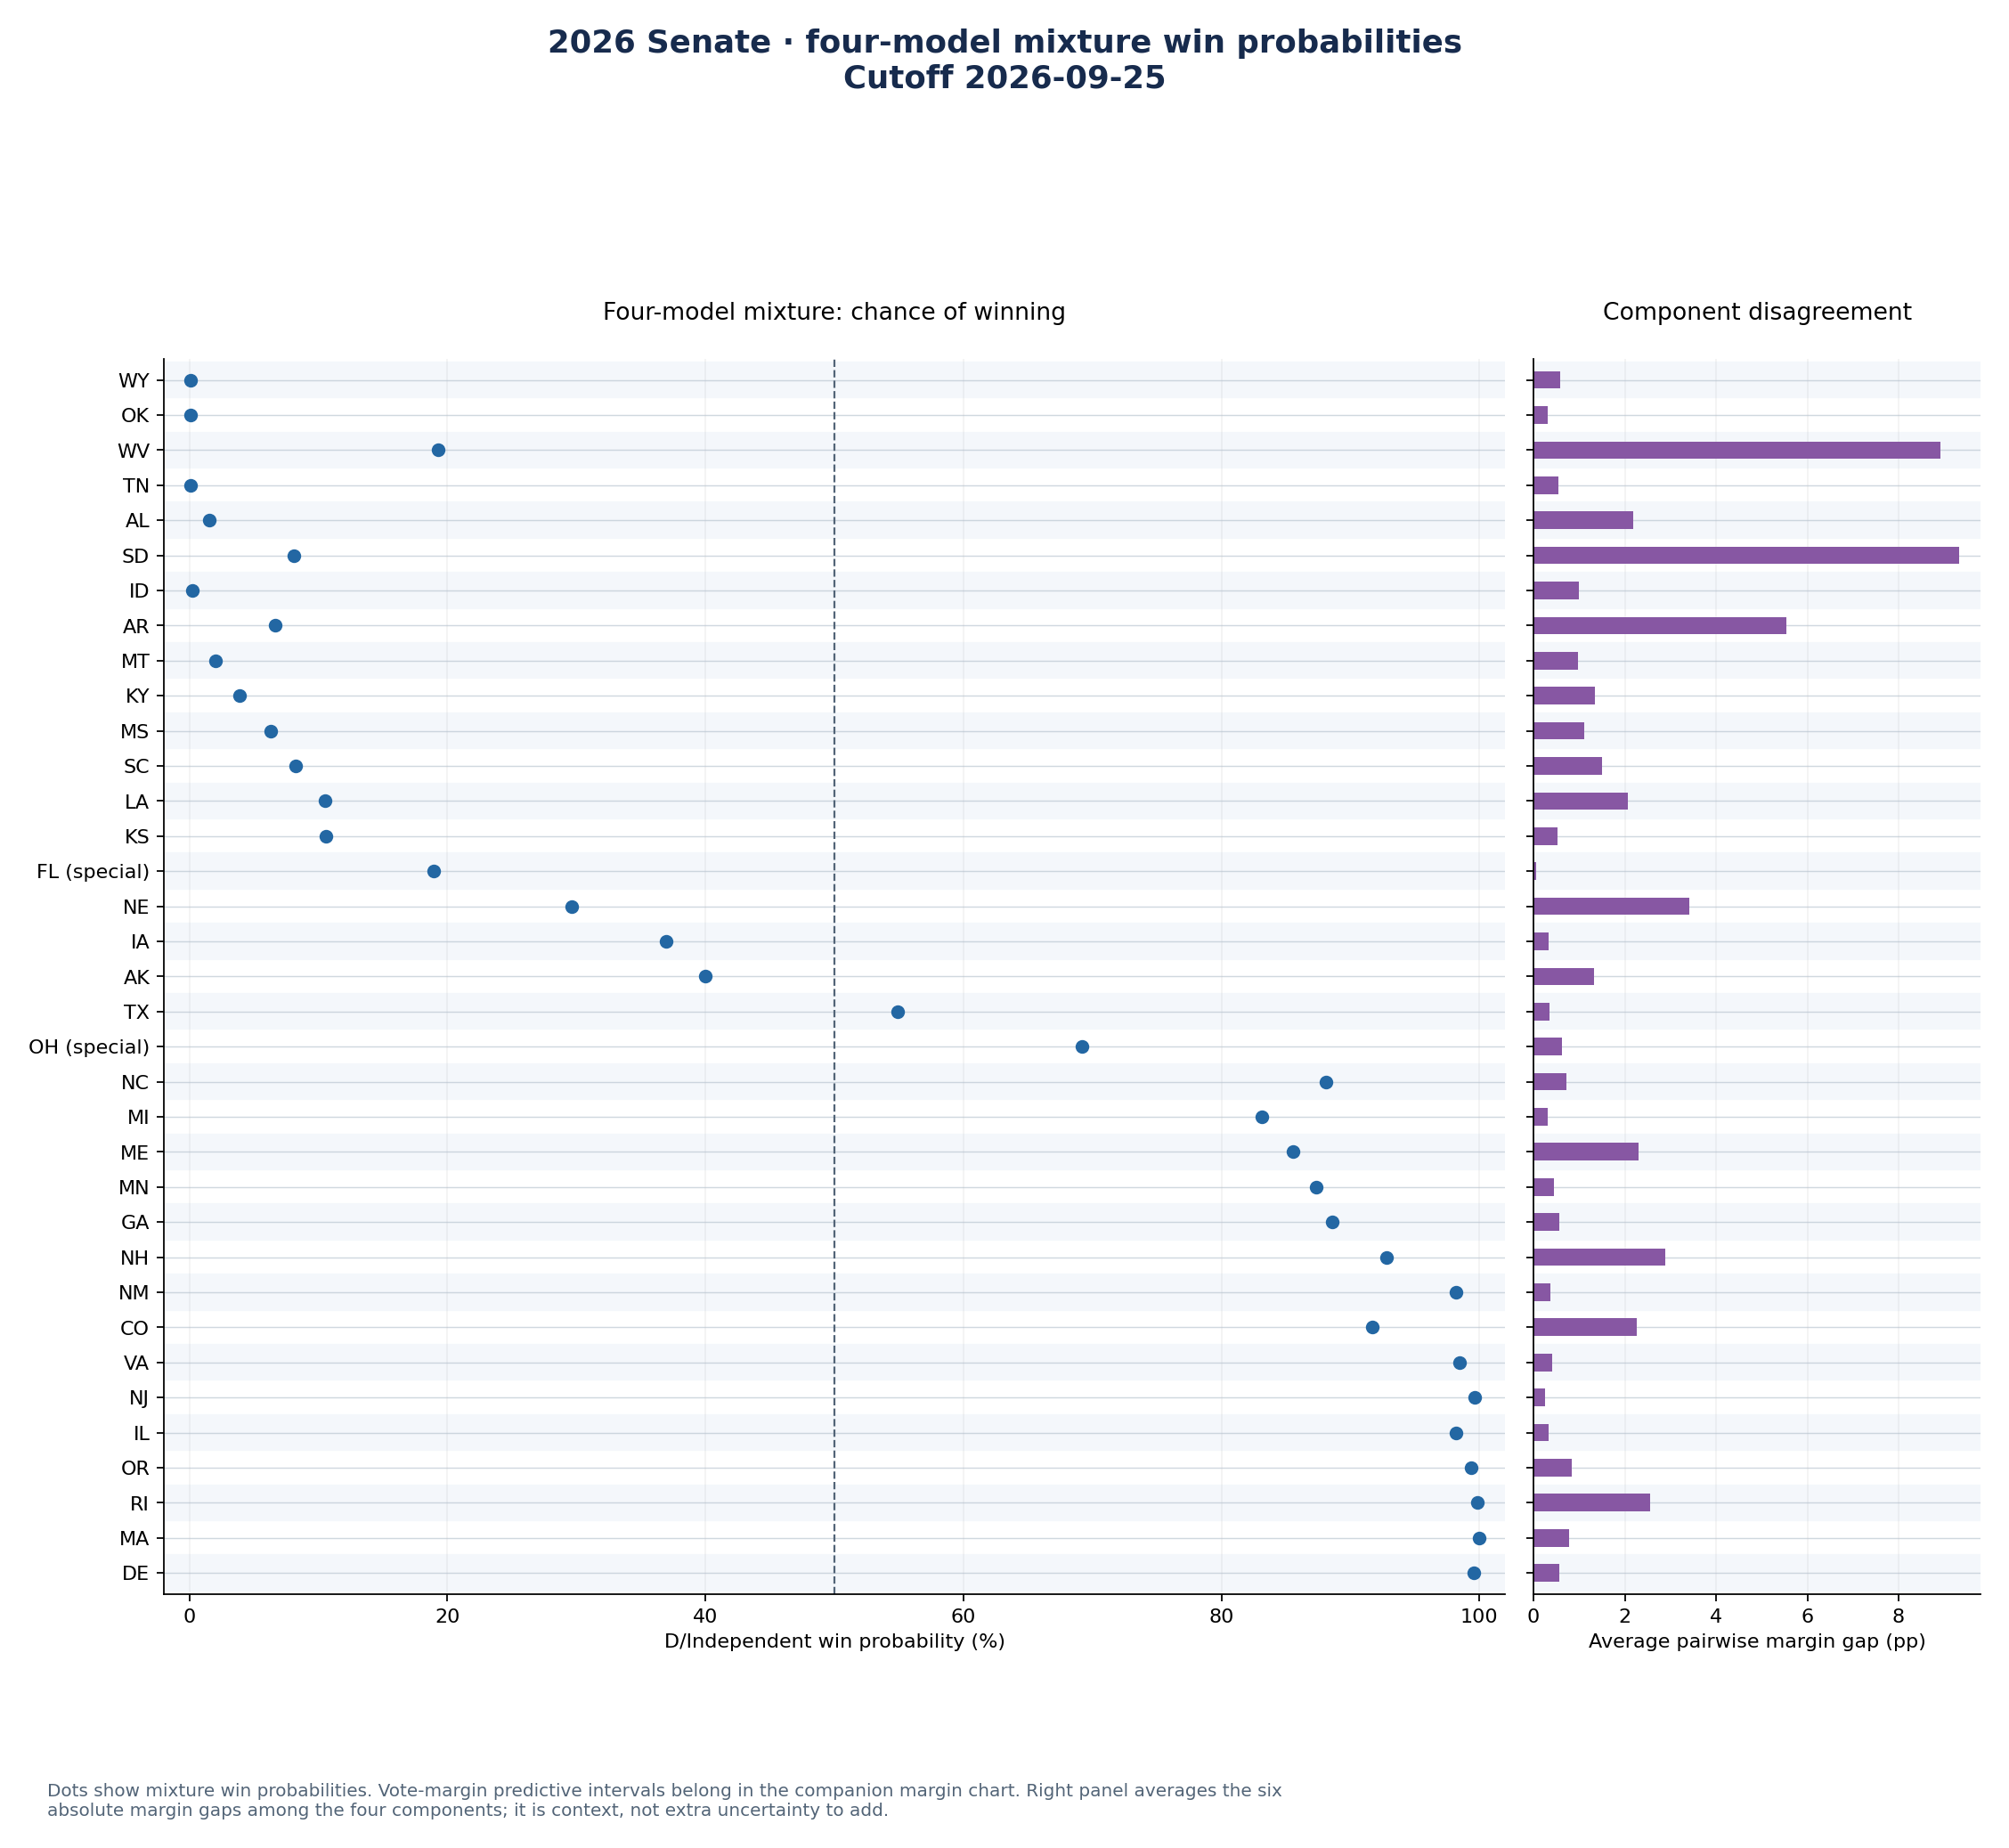

In [6]:
# Reload chart styling even when this cell runs in an existing kernel.
import importlib, live_share_images
importlib.reload(live_share_images)

print('D/Independent−R margins (pp)')
show=[m for m in DISPLAY_MODELS if m in tables['margins'].columns]
display(tables['margins'][show].round(2))
print('D/Independent win probabilities (%)')
display(tables['probabilities'][show].round(1))
from live_uncertainty_watchlist import build_watchlist
state_coverage = build_watchlist(RUN, DISPLAY_MODELS, recent_days=RECENT_DAYS,
    min_width_pp=MIN_95_WIDTH_PP, min_samples=MIN_RECENT_SAMPLES, min_firms=MIN_RECENT_FIRMS)
live_share_images.display_images(live_share_images.state_images(
    tables, show, SHARE_DIR, meta['as_of'], coverage=state_coverage))


## 5. Wide uncertainty despite recent polling

This watchlist ranks **uncertainty in the margin**, not closeness to a 50/50 win probability. It uses this run's cutoff and dataset, so Run All automatically updates the list after refreshing data.

Defaults: an eligible poll ending within **30 days** (age 0–30 inclusive), and a **95% interval at least 25 percentage points wide**. A stronger-coverage flag requires **3 distinct recent samples from at least 2 identified firms**. These adjustable thresholds are descriptive, not learned. Dates are field-end dates; unknown publication dates retain the forecast's existing screening policy. Multiple question versions from the same sample count once.

The first table shows qualifying states under the main Gaussian. The second applies the same filter to every displayed model. `watchlist['recent']` retains all recently polled states and models, including those below the width threshold; `watchlist['broad']` contains all qualifying rows. Positive margins mean D−R in percentage points.

Missing polls can leave broad priors; one recent poll does not eliminate sparse-evidence uncertainty. Wide intervals alone do **not** establish fat tails or a likely political shock. The non-Bayesian helper has a common error spread across states, and mean-only blends preserve their base distribution's centered uncertainty. Student intervals use saved sampled quantiles, not a Gaussian approximation.


As of 2026-09-25: recent = age 0–30 days; broad = 95% interval width ≥ 25 pp
Stronger coverage = ≥3 samples from ≥2 firms.


,latest_poll,recent_samples,recent_firms,stronger_coverage,prediction_pp,lo95_pp,hi95_pp,width95_pp
contest,,,,,,,,
SD,2026-09-09,1,1,False,-27.3,-43.8,-10.7,33.1
NM,2026-08-28,1,1,False,15.8,0.9,30.8,29.9
NE,2026-09-16,3,3,True,-7.1,-21.5,7.4,28.9
MT,2026-09-15,3,3,True,-13.1,-26.7,0.5,27.2
RI,2026-09-21,1,1,False,25.7,12.6,38.7,26.1
MN,2026-09-15,4,4,True,6.8,-6.1,19.7,25.8
FL special,2026-09-21,5,5,True,-5.9,-18.7,6.9,25.7
TN,2026-08-26,1,1,False,-22.5,-35.2,-9.8,25.5


,recent_contests,broad_contests,states,stronger_coverage_states
model,,,,
Gaussian Bayesian,23,8,"SD, NM, NE, MT, RI, MN, FL special, TN","NE, MT, MN, FL special"
Matched Student-t (df5),23,3,"SD, NE, NM",NE
Older Gaussian,23,18,"SD, FL special, NE, RI, NM, TN, LA, KY, AK, SC, GA, MT, ME, MI, IA, NH, MA, MN","FL special, NE, AK, GA, MT, ME, MI, IA, NH, MN"
Student-t research helper,23,8,"SD, RI, NM, NE, FL special, TN, LA, KY","NE, FL special"
Empirical baseline,23,23,"AK, FL special, GA, IA, ID, KS, KY, LA, MA, ME, MI, MN, MT, NC, NE, NH, NM, OH special, RI, SC, SD, TN, TX","AK, FL special, GA, IA, KS, ME, MI, MN, MT, NC, NE, NH, OH special, TX"
Four-model mixture,23,10,"SD, NE, NM, RI, FL special, TN, LA, MT, KY, AK","NE, FL special, MT, AK"
Mixture: 20% shift toward baseline,23,10,"SD, NE, NM, RI, FL special, TN, LA, MT, KY, AK","NE, FL special, MT, AK"


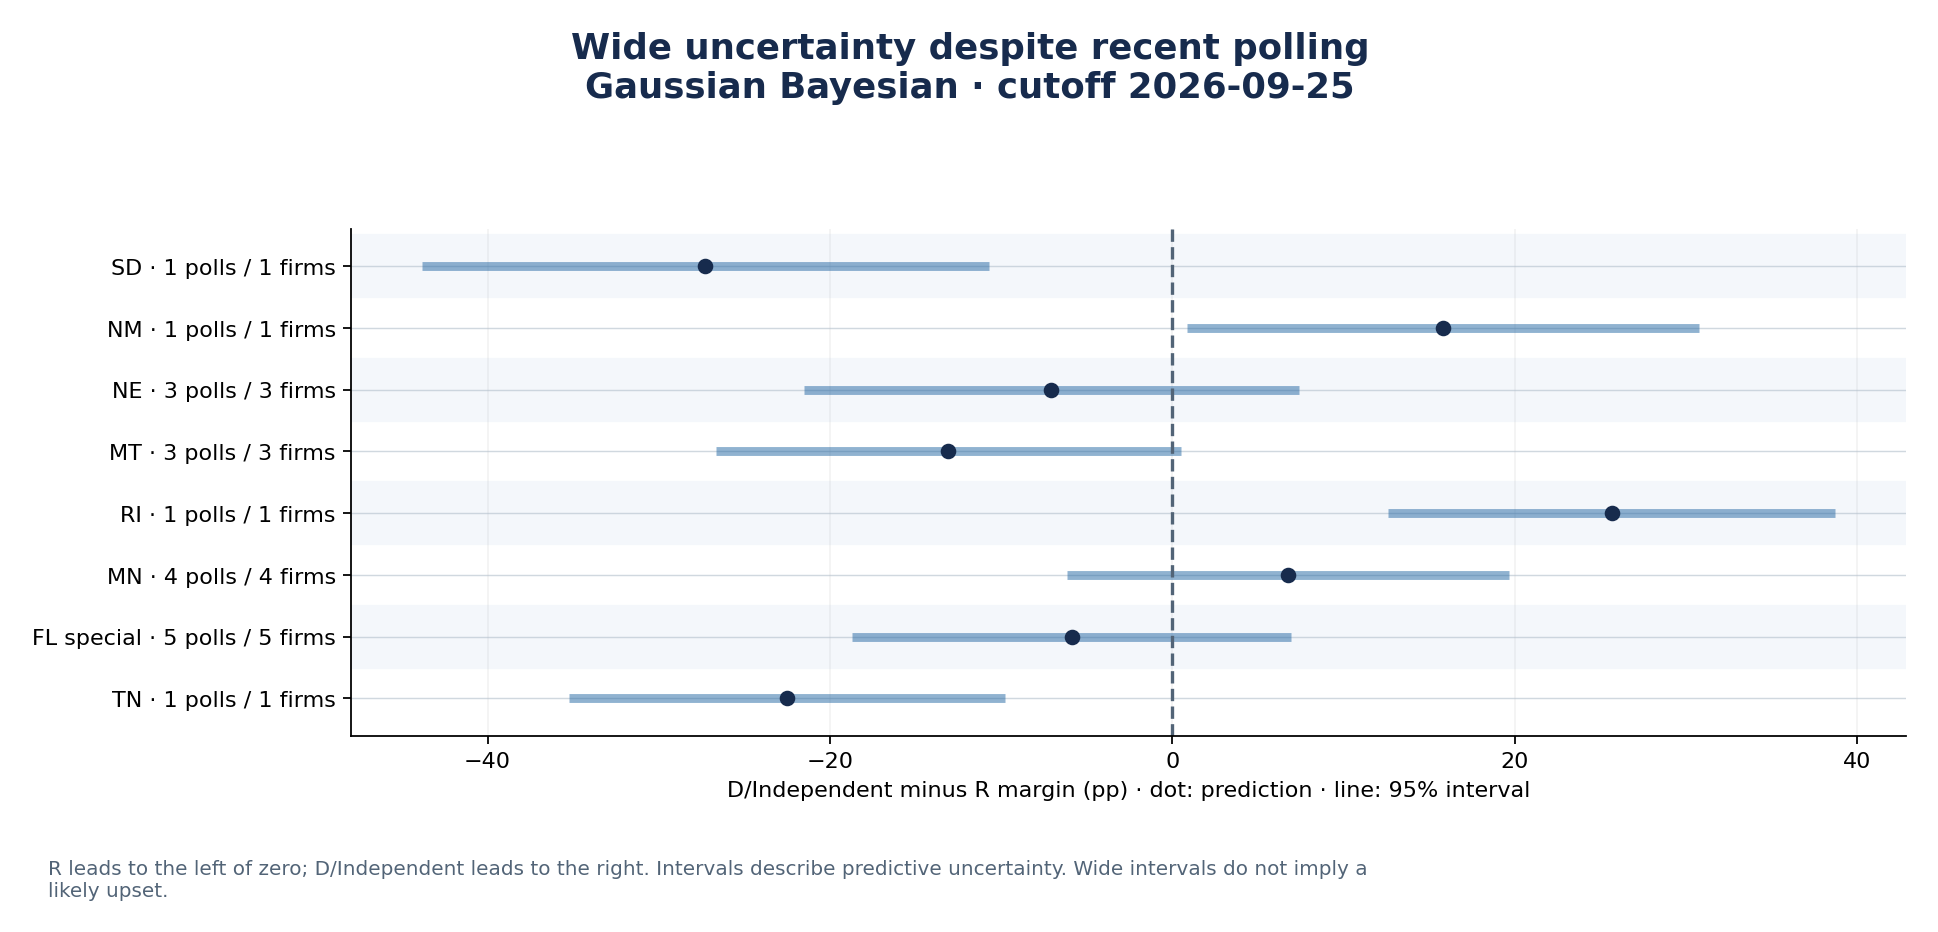

In [7]:
# Reload chart styling even when this cell runs in an existing kernel.
import importlib, live_share_images
importlib.reload(live_share_images)

from live_uncertainty_watchlist import build_watchlist


watchlist = build_watchlist(
    RUN, DISPLAY_MODELS, recent_days=RECENT_DAYS, min_width_pp=MIN_95_WIDTH_PP,
    min_samples=MIN_RECENT_SAMPLES, min_firms=MIN_RECENT_FIRMS,
)
print(f"As of {watchlist['as_of']}: recent = age 0–{RECENT_DAYS} days; "
      f"broad = 95% interval width ≥ {MIN_95_WIDTH_PP:g} pp")
print(f"Stronger coverage = ≥{MIN_RECENT_SAMPLES} samples from ≥{MIN_RECENT_FIRMS} firms.")
main_watch = watchlist['broad'].query("model == 'Bayesian'")
if main_watch.empty:
    print('No main-model states meet both the recency and width filters.')
else:
    display(main_watch[['contest', 'latest_poll', 'recent_samples', 'recent_firms',
                        'stronger_coverage', 'prediction_pp', 'lo95_pp', 'hi95_pp',
                        'width95_pp']].set_index('contest').round(1))
with pd.option_context('display.max_colwidth', None):
    display(watchlist['summary'].set_index('model'))

live_share_images.display_images(live_share_images.uncertainty_images(main_watch, SHARE_DIR, meta['as_of']))


## 5b. Races to watch: likely outcome and room for a surprise

Two tables separate adequate polling from thin/no recent polling. Each lists the likely winner, reference-model margin and 95% range, probability the other party wins, average core-model disagreement, and predictive standard deviation. Zero-recent-poll races remain eligible.

Within each group, we take the union of the top three races for disagreement, predictive uncertainty, other-winner probability, and historical mean absolute error (requiring at least two past races). Reasons explain each selection; this is a descriptive screen, not an estimated probability of surprising the public. Historical context uses up to three past **state** races in September backtests (not necessarily the same Senate seat), excluding the current cycle. Past misses do not change current forecasts.

Reference-model winner, margin, 95% interval and other-winner probability describe the likely outcome and its alternatives. Disagreement is the mean absolute pairwise difference in core-model margins. Predictive SD is the square root of the mean within-model variance, not variance between model means. Blends/mixtures are excluded; the core models share evidence and are not independent votes. Within each polling group, select the top 3 races on each of disagreement, predictive SD, reference-model other-winner probability, and historical mean absolute error (at least two past races); take their union and order by other-winner probability. Ties are broken by contest name. This is a review screen, not a calibrated probability of surprising the public. History uses the last three completed state races in September backtests before the current cycle; it can include other Senate seats and special elections. These are reconstructed forecasts, not issued forecasts. Past errors are context and do not alter current probabilities.

Forecast cutoff: 2026-09-25
Core models: Gaussian Bayesian, Matched Student-t (df5), Older Gaussian, Student-t research helper, Empirical baseline


### Adequately polled races

Race,Likely winner,D−R margin,95% range (pp),Other winner %,Disagreement (pp),Predictive SD (pp),Recent polls / firms,Past state surprises,Why watch
TX,D,0.8,-8.7 to 10.4,43.3,0.4,7.0,12 / 12,The largest miss was 5.1 pp in 2018. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Other-winner probability ranks #1 in this group.
IA,R,-2.1,-13.8 to 9.5,36.2,1.2,7.6,9 / 9,The largest miss was 10.4 pp in 2016. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Other-winner probability ranks #2 in this group.
AK,R,-2.5,-14.0 to 9.1,33.9,1.2,7.9,3 / 3,No comparable history is available.,Other-winner probability ranks #3 in this group.
FL special,R,-5.9,-18.7 to 6.9,18.5,2.2,8.4,5 / 5,The largest miss was 12.4 pp in 2022. 1 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Predictive uncertainty ranks #2 in this group. Past margin error ranks #3 in this group. 1 of 3 past results fell outside the 95% range.
NE,R,-7.1,-21.5 to 7.4,16.9,3.0,8.7,3 / 3,The largest miss was 22.2 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Predictive uncertainty ranks #1 in this group. Past margin error ranks #1 in this group.
MI,D,5.8,-5.9 to 17.4,16.6,3.8,7.7,11 / 11,The largest miss was 11.9 pp in 2018. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Past margin error ranks #2 in this group. Models disagree on the winner.
ME,D,8.4,-3.0 to 19.7,7.4,4.3,7.8,7 / 7,No comparable history is available.,Model disagreement ranks #1 in this group. Models disagree on the winner.
MT,R,-13.1,-26.7 to 0.5,3.0,3.8,8.1,3 / 3,The largest miss was 8.8 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #3 in this group. Predictive uncertainty ranks #3 in this group.
NH,D,11.5,0.4 to 22.5,2.1,4.0,7.6,4 / 4,The largest miss was 4.3 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 1 of 3 races.,Model disagreement ranks #2 in this group.


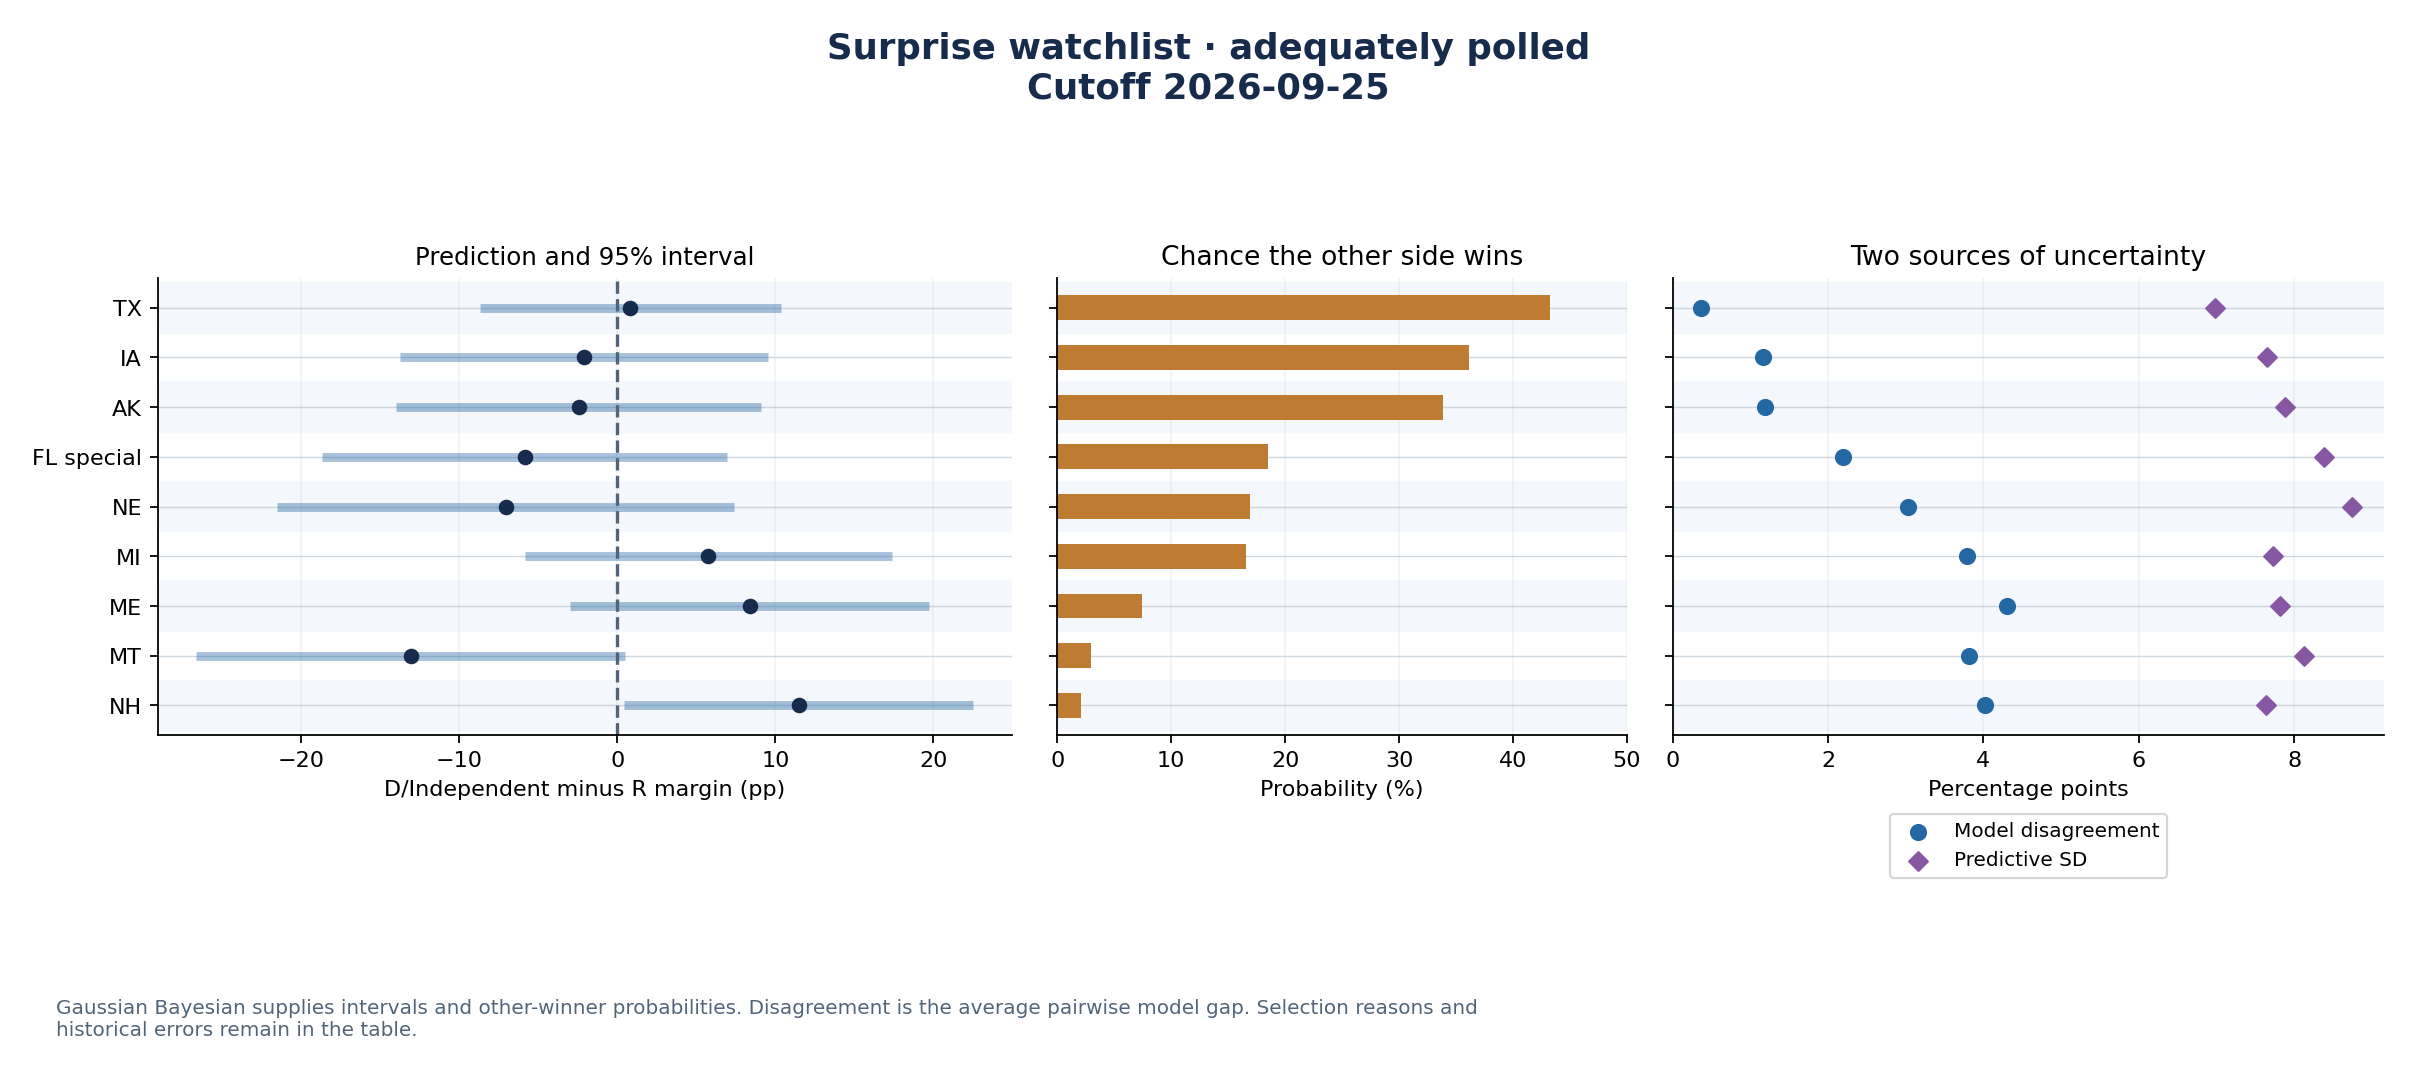

### Thinly polled / no recent polls

Race,Likely winner,D−R margin,95% range (pp),Other winner %,Disagreement (pp),Predictive SD (pp),Recent polls / firms,Past state surprises,Why watch
WV,R,-31.3,-71.5 to 8.9,6.3,10.5,31.0,0 / 0,The largest miss was 47.9 pp in 2020. 1 of 3 results fell outside the 95% range. It missed the winner in 1 of 3 races.,Model disagreement ranks #1 in this group. Predictive uncertainty ranks #1 in this group. Other-winner probability ranks #1 in this group. Past margin error ranks #2 in this group. There are no recent eligible polls. 1 of 3 past results fell outside the 95% range.
CO,D,18.6,-4.9 to 42.0,6.0,5.8,12.6,0 / 0,The largest miss was 8.1 pp in 2022. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Predictive uncertainty ranks #2 in this group. Other-winner probability ranks #2 in this group. There are no recent eligible polls.
LA,R,-9.9,-21.7 to 2.0,5.1,1.8,8.1,1 / 1,No comparable history is available.,Other-winner probability ranks #3 in this group. Recent polling is limited.
AR,R,-20.0,-33.9 to -6.1,0.2,6.5,9.6,0 / 0,The largest miss was 16.7 pp in 2022. 2 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Past margin error ranks #3 in this group. There are no recent eligible polls. 2 of 3 past results fell outside the 95% range.
OR,D,24.2,9.3 to 39.1,0.1,6.6,9.7,0 / 0,The largest miss was 9.7 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #3 in this group. There are no recent eligible polls.
SD,R,-27.3,-43.8 to -10.7,0.1,9.9,11.5,1 / 1,The largest miss was 32.0 pp in 2016. 1 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #2 in this group. Predictive uncertainty ranks #3 in this group. Past margin error ranks #1 in this group. Recent polling is limited. 1 of 3 past results fell outside the 95% range.


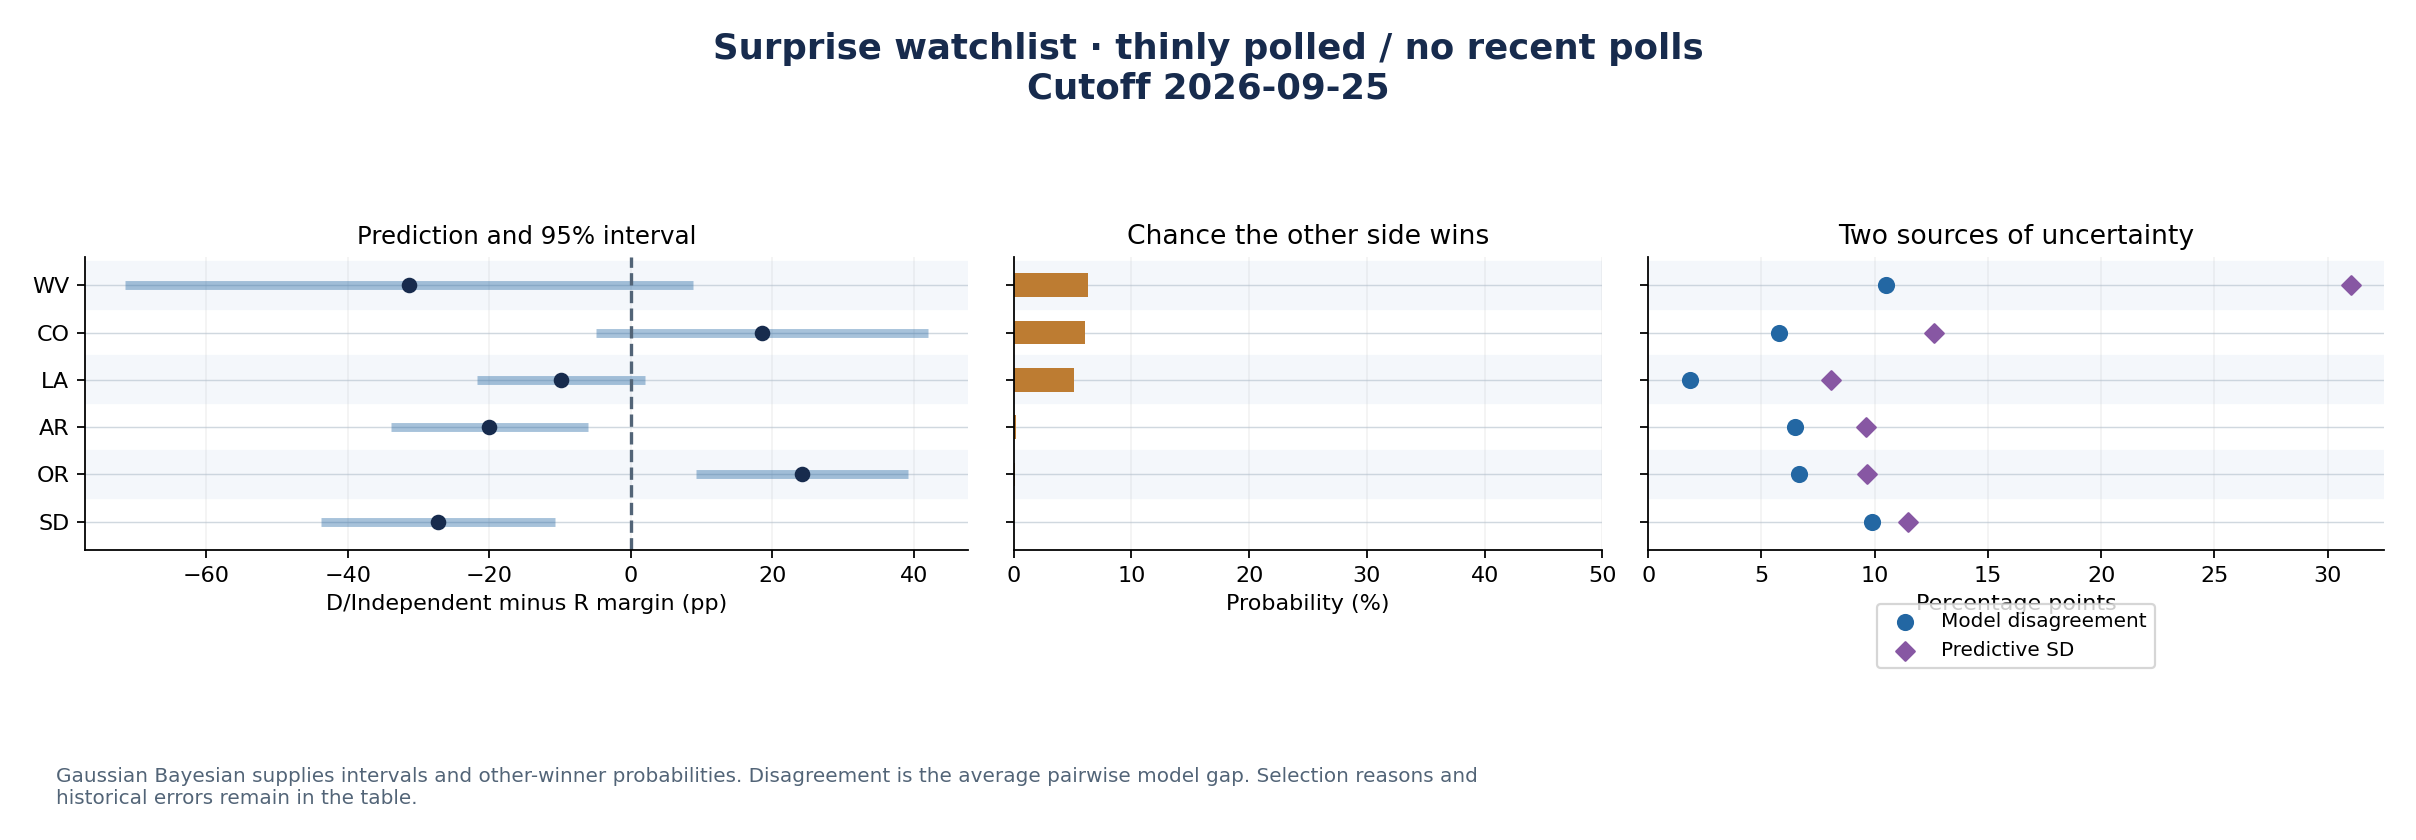

In [8]:
# Reload chart styling even when this cell runs in an existing kernel.
import importlib, live_share_images
importlib.reload(live_share_images)

from pathlib import Path
import sys, importlib
from IPython.display import Markdown
from model_labels import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'election_lab.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import election_lab as lab
from model_labels import display, model_label
import live_uncertainty_watchlist
import live_surprise_watchlist
importlib.reload(live_uncertainty_watchlist)
importlib.reload(live_surprise_watchlist)
from live_surprise_watchlist import build_surprise_watchlist, render_table, METHOD

if 'RUN' not in globals():
    RUN = lab.latest_run('live')
surprise = build_surprise_watchlist(
    RUN, recent_days=globals().get('RECENT_DAYS', 30),
    min_samples=globals().get('MIN_RECENT_SAMPLES', 3),
    min_firms=globals().get('MIN_RECENT_FIRMS', 2), top_n=3,
)
display(Markdown(METHOD))
print('Forecast cutoff:', surprise['parameters']['as_of'])
print('Core models:', ', '.join(map(model_label, surprise['parameters']['available_models'])))
for key, title in [('polled', 'Adequately polled races'), ('thin', 'Thinly polled / no recent polls')]:
    display(Markdown('### ' + title))
    display(render_table(surprise[key]))
    live_share_images.display_images(live_share_images.watch_images(surprise[key], key, SHARE_DIR, surprise['parameters']['as_of']))


## 5c. Compare with published forecasts

This cell automatically retrieves Race to the WH probabilities, Inside Elections ratings, and a dated public Silver Bulletin Deluxe Senate-control probability. Silver’s state forecasts and expected seats are not available in the public text. It compares Senate control, expected seats, and state races. It selects different favored winners and large probability gaps using the thresholds below. Full sentences explain each selection. Source dates, unavailable sources, and excluded contests are shown. The same comparison is saved in the report; no text or forecast values need to be entered manually.

Independent candidates count on the D/Independent side for this comparison. Separate D and independent win probabilities are added once. This assumption is recorded in the report.

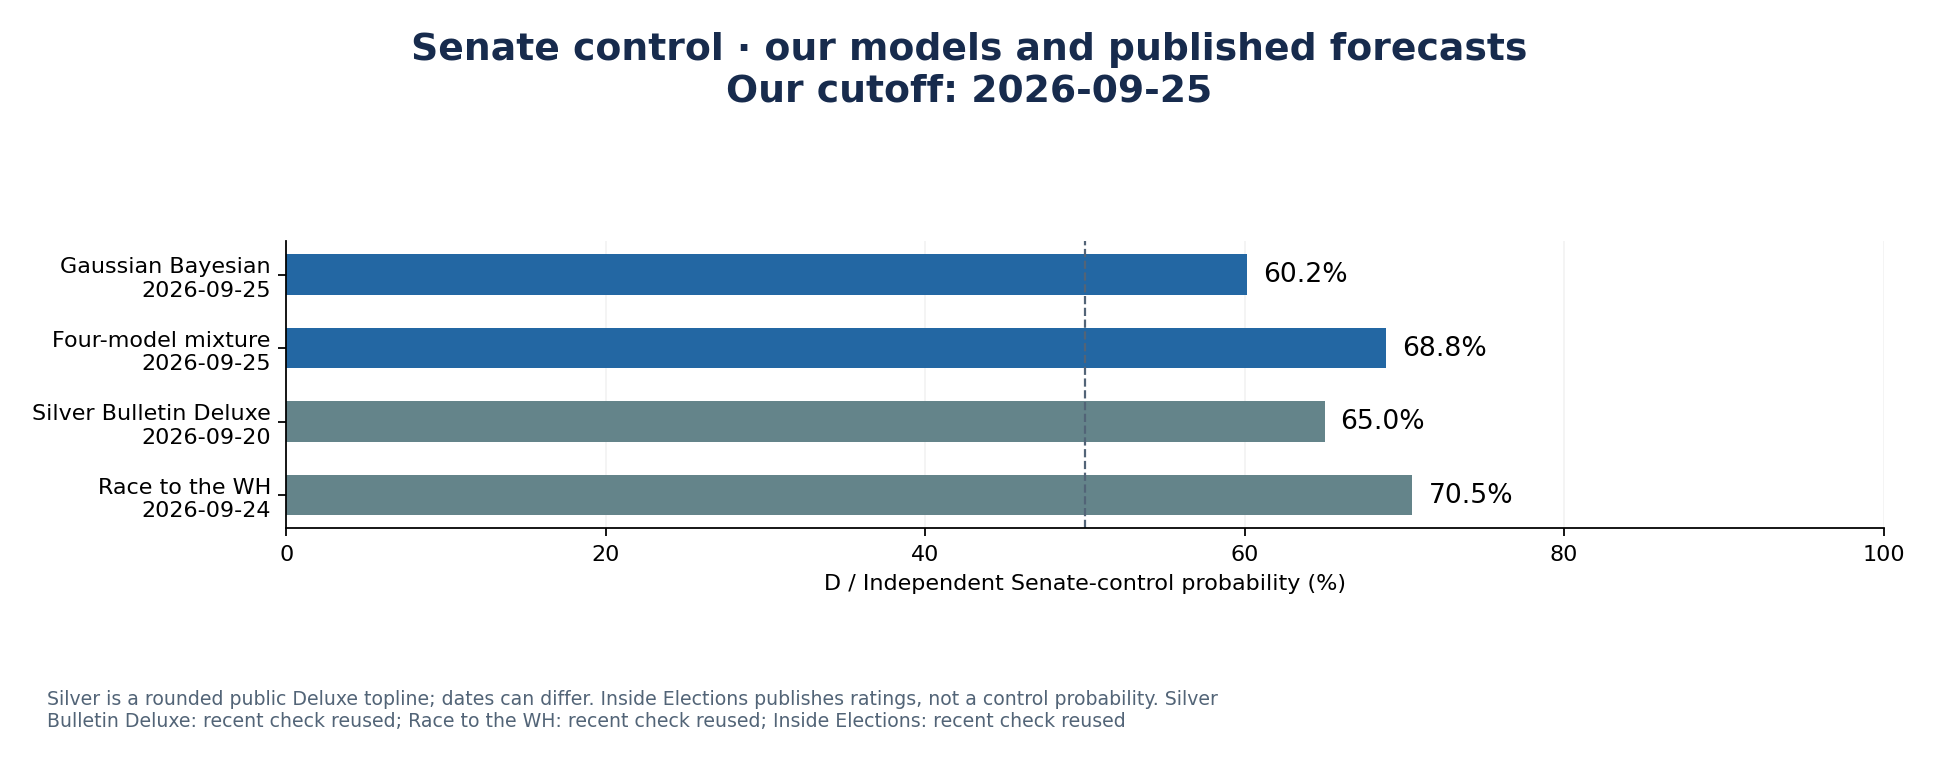

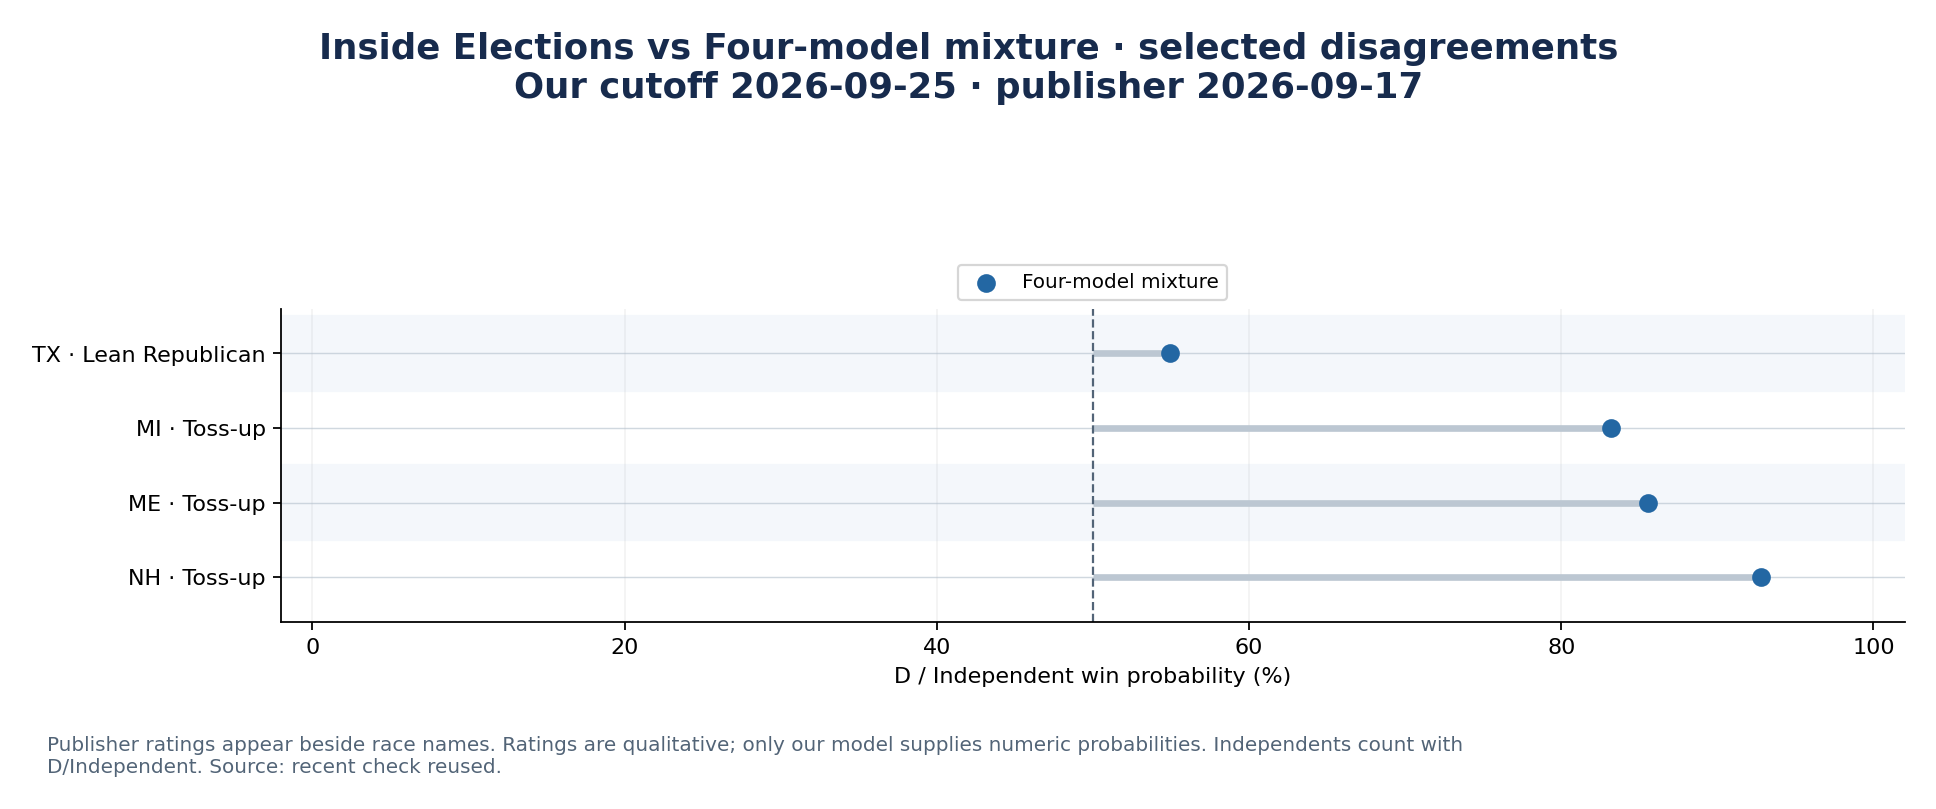

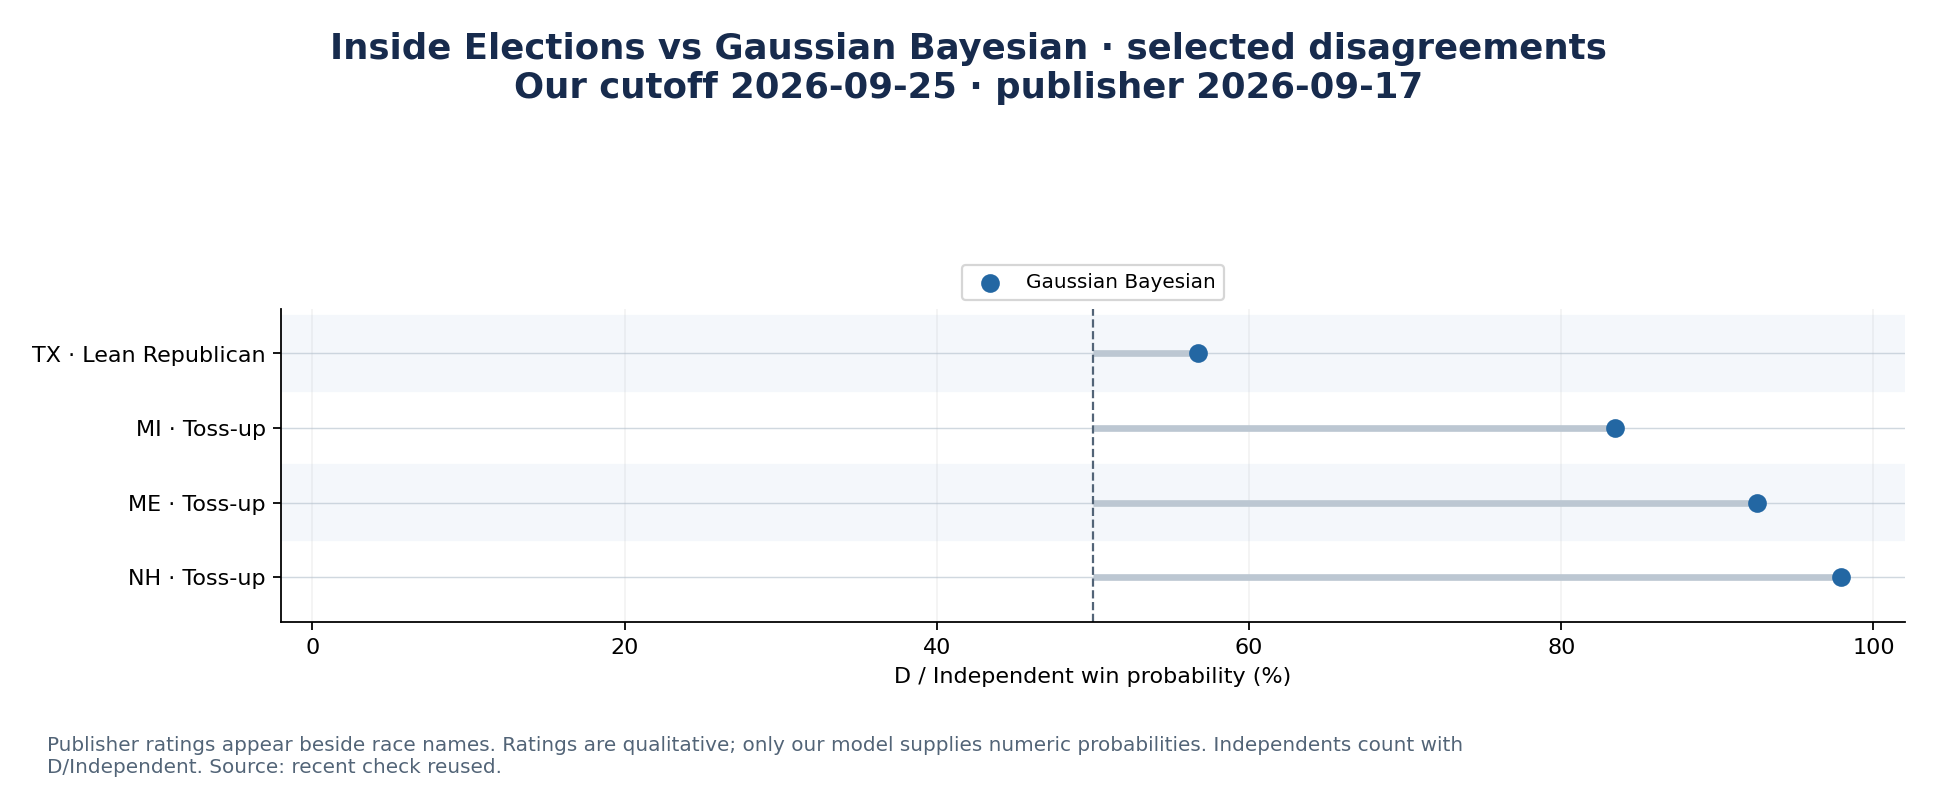

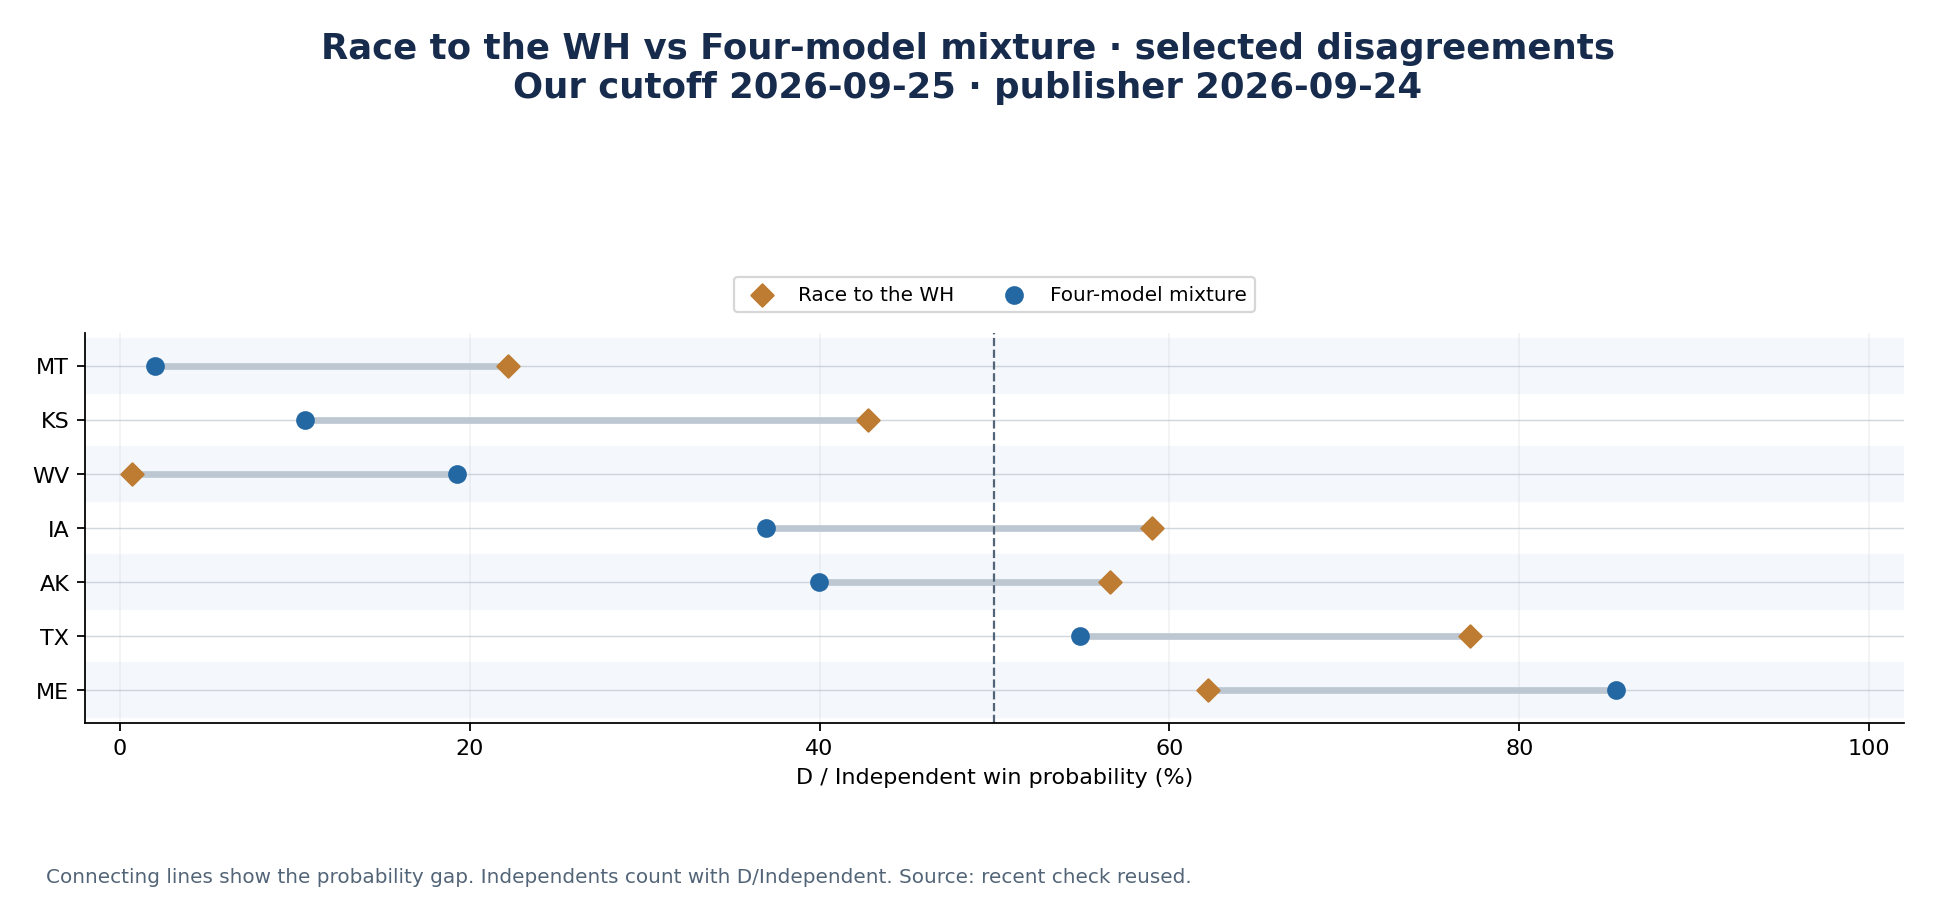

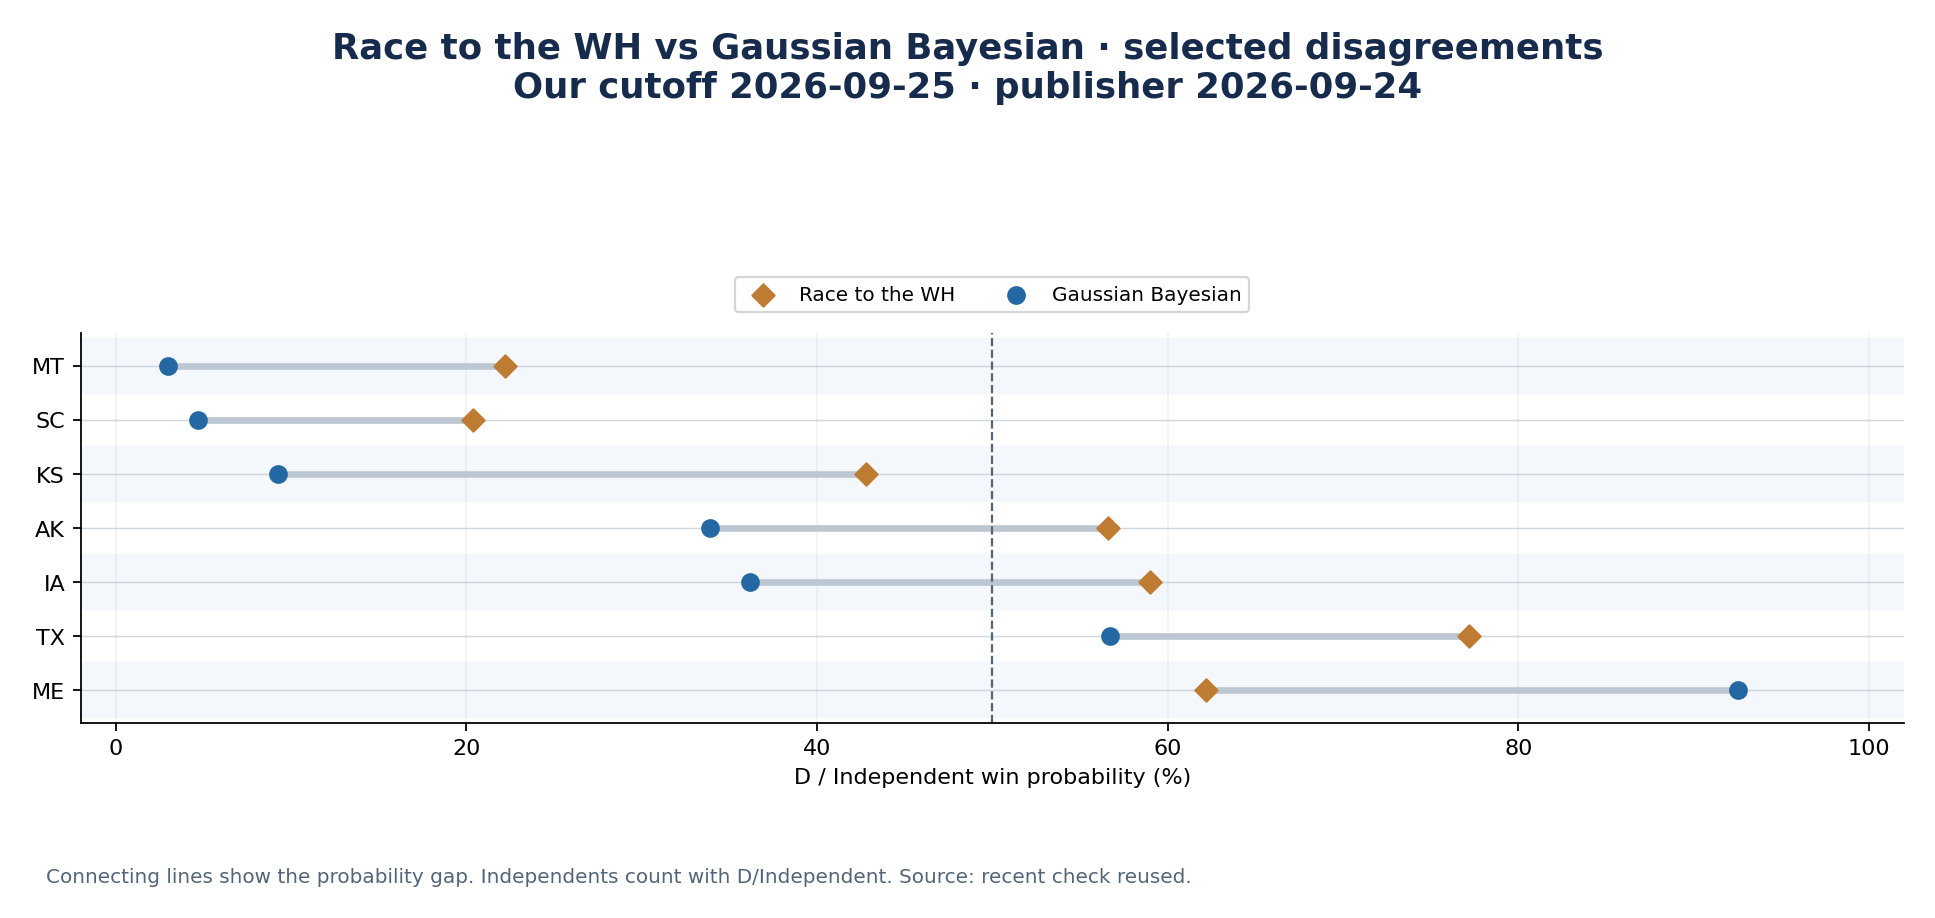

In [9]:
# Reload chart styling even when this cell runs in an existing kernel.
import importlib, live_share_images
importlib.reload(live_share_images)

from live_published_comparison import build_published_comparison, render_comparison

PUBLISHED_GAP_PP = 15
PUBLISHED_RATING_CONFIDENCE = .75
PUBLISHED_MODELS = ('Bayesian', 'Four-model mixture')
published = build_published_comparison(
    RUN, offline=OFFLINE, force=FORCE, ttl_hours=TTL_HOURS, timeout=TIMEOUT_SECONDS,
    gap_pp=PUBLISHED_GAP_PP, confidence=PUBLISHED_RATING_CONFIDENCE, models=PUBLISHED_MODELS,
)
display(render_comparison(published))
live_share_images.display_images(live_share_images.published_images(published, SHARE_DIR, meta['as_of']))


## 6. Senate-control probabilities over cutoff dates

Reconstruct the direction of the forecast from January2026: evaluate every `HISTORY_EVERY_DAYS` days **plus each of the last three calendar days**, always including the endpoint. The default30-day grid is inexpensive; change it to7 for weekly detail. All models in the current live run are included, including every retained mean-shift weight. Republican control includes a50–50 Senate under the assumed Republican VP tie-break, so the two control probabilities sum to100%.

**This is a retrospective fixed-model replay, not a history of forecasts issued at the time.** Trained coefficients, priors, normalizers, hyperparameters, roster and screening rules stay fixed. Each cutoff rescreens polls by field-end and known release dates and recomputes decay. Unknown release dates use field-end dates; later archives cannot perfectly reconstruct publication availability or old candidate choices. `dated` also recomputes economic/approval features from reference periods ending by that cutoff, using today's revised source history. Those reference periods do not guarantee publication availability. `fixed_latest` is an optional polling-only sensitivity that deliberately holds today's features fixed.

The models were calibrated at September/October horizons, so January probabilities are exploratory. Small daily movements, particularly for Student models, may include Monte Carlo noise. The lines connect evaluated cutoffs, not daily forecasts between those dates. Student models run their actual samplers and convergence checks. Unchanged cutoff inputs reuse verified caches; changed inputs recompute.

A current-only HTML report is saved before the history starts, so it remains available even if a later replay fails. The following section then saves the complete report with the history. No existing forecast artifact is overwritten.


Current report saved: /Users/amir/projects/small_models/us_election_2026/cache/runs/live_reports/20260925T165503.952376Z/report.html


Cutoff 1/12: 2026-01-01 — computed


Cutoff 2/12: 2026-01-31 — computed


Cutoff 3/12: 2026-03-02 — computed


Cutoff 4/12: 2026-04-01 — computed


...

Political context: carrying forward the 2026-09-17 review; not independently reverified.


Cutoff 11/12: 2026-09-24 — computed


Cutoff 12/12: 2026-09-25 — current_live_run


Last daily cutoff probabilities (%), both parties and all models:


D_control_pct                        \
date                                   2026-09-23 2026-09-24 2026-09-25   
model                                                                     
Gaussian Bayesian                           59.85      59.34      60.17   
Gaussian: 10% shift toward baseline         56.07      55.34      56.30   
Gaussian: 20% shift toward baseline         52.14      51.59      52.62   
Gaussian: 40% shift toward baseline         44.72      44.27      45.35   
Gaussian: 50% shift toward baseline         41.37      40.99      42.08   
Four-model mixture                          68.50      67.96      68.82   
Matched Student-t (df5)                     63.46      62.55      63.50   
Mixture: 10% shift toward baseline          64.60      63.98      64.95   
Mixture: 20% shift toward baseline          60.33      59.82      60.88   
Mixture: 30% shift toward baseline          55.95      55.51      56.60   
Mixture: 40% shift toward baseline          51.45      51.07      52.20   
Mixture: 5% shift toward baseline           66.58      66.00      66.92   
Mixture: 50% shift toward baseline          46.96      46.63      47.76   
Empirical baseline                          31.63      31.79      32.37   
Older Gaussian                              74.64      74.38      75.12   
Student-t research helper                   76.07      75.57      76.50   

                                    R_control_pct                        
date                                   2026-09-23 2026-09-24 2026-09-25  
model                                                                    
Gaussian Bayesian                           40.15      40.66      39.83  
Gaussian: 10% shift toward baseline         43.93      44.66      43.70  
Gaussian: 20% shift toward baseline         47.86      48.41      47.38  
Gaussian: 40% shift toward baseline         55.28      55.73      54.65  
Gaussian: 50% shift toward baseline         58.63      59.01      57.92  
Four-model mixture                          31.50      32.04      31.18  
Matched Student-t (df5)                     36.54      37.45      36.50  
Mixture: 10% shift toward baseline          35.40      36.02      35.05  
Mixture: 20% shift toward baseline          39.67      40.18      39.12  
Mixture: 30% shift toward baseline          44.05      44.49      43.40  
Mixture: 40% shift toward baseline          48.55      48.93      47.80  
Mixture: 5% shift toward baseline           33.42      34.00      33.08  
Mixture: 50% shift toward baseline          53.04      53.37      52.24  
Empirical baseline                          68.37      68.21      67.63  
Older Gaussian                              25.36      25.62      24.88  
Student-t research helper                   23.93      24.43      23.50

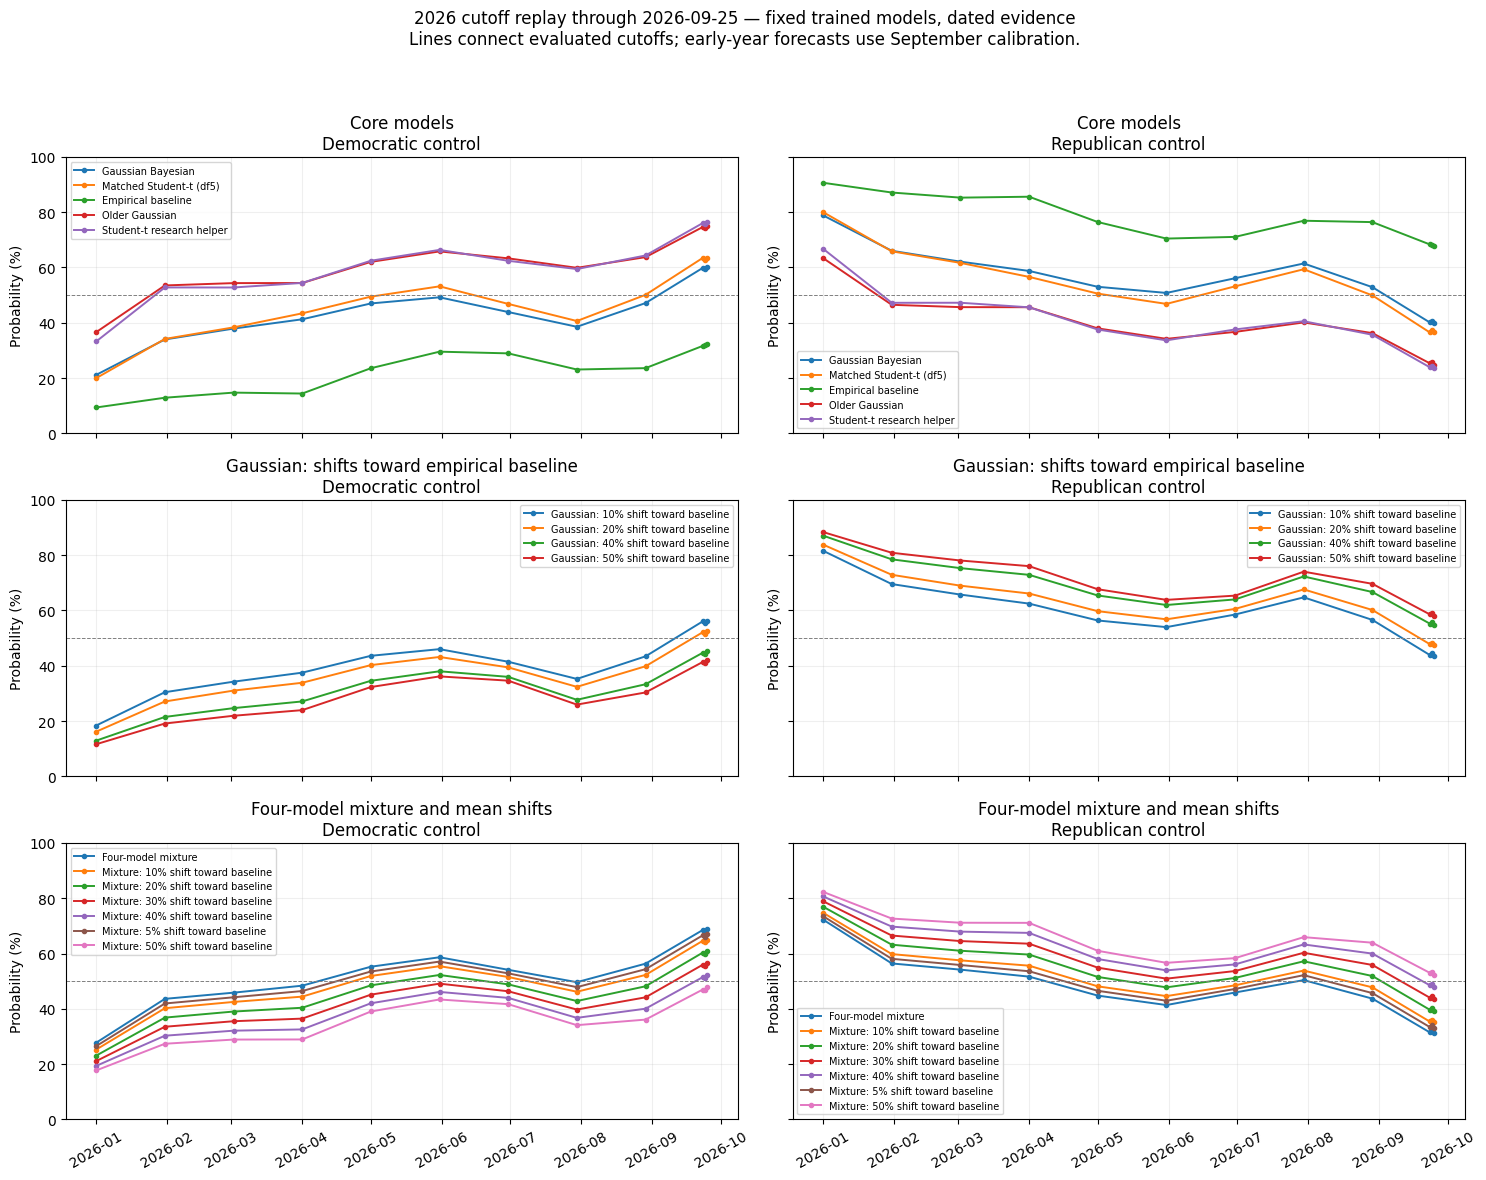

In [10]:
import importlib, live_forecast_report
importlib.reload(live_forecast_report)
from live_forecast_report import run_history, history_figure, recent_table, save_report

HISTORY_START = '2026-01-01'
HISTORY_EVERY_DAYS = 30
HISTORY_LAST_DAYS = 3
HISTORY_FEATURE_MODE = 'dated'  # or 'fixed_latest' to isolate polling changes
HISTORY_FORCE = False

CURRENT_REPORT = save_report(RUN, watchlist, surprise=surprise, published=published)
print('Current report saved:', CURRENT_REPORT/'report.html')
HISTORY_RUN = run_history(
    RUN, start=HISTORY_START, every_days=HISTORY_EVERY_DAYS,
    last_days=HISTORY_LAST_DAYS, feature_mode=HISTORY_FEATURE_MODE, force=HISTORY_FORCE,
)
control_history = pd.read_parquet(HISTORY_RUN/'control_history.parquet')
print('Last daily cutoff probabilities (%), both parties and all models:')
display(recent_table(control_history, HISTORY_LAST_DAYS))
fig = history_figure(control_history)
SHARE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(SHARE_DIR/'control_history.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)


## 7. Save the complete report

Every Run All saves a timestamped **self-contained HTML report** with the current chamber/state forecasts, uncertainty watchlist, both-party control-history plots, recent daily tables, all cutoff results, polling coverage and provenance. Its chart is embedded, so the HTML file can be shared on its own. Machine-readable Parquet tables and a PNG chart are saved alongside it. The latest published report is under `outputs/reports/forecast/`; dated reports are under `outputs/reports/history/`.

Shareable PNG images are generated automatically for chamber results, state forecasts, watchlists and published comparisons. The original tables remain available. PNGs are saved alongside the latest report and frozen in the dated report folder.


In [11]:
import os

REPORT = save_report(RUN, watchlist, HISTORY_RUN, surprise=surprise, published=published)
print('Complete report saved:', REPORT/'report.html')
lab.verify_run(REPORT)

print('Shareable PNGs:', ROOT/'outputs/reports/forecast')
print('Dated reports and images:', ROOT/'outputs/reports/history')


Complete report saved: /Users/amir/projects/small_models/us_election_2026/cache/runs/live_reports/20260925T165700.979963Z/report.html
Shareable PNGs: /Users/amir/projects/small_models/us_election_2026/outputs/reports/forecast
Dated reports and images: /Users/amir/projects/small_models/us_election_2026/outputs/reports/history


## 8. Saved provenance and uncertainty checks

The entire run can be reopened by its path without following a later pointer. For an offline fresh recomputation use `python run.py live --offline`. For exact original research numbers use notebook01 instead.

In [12]:
lab.verify_run(RUN)
pred=pd.read_parquet(RUN/'predictions.parquet')
assert pred.actual_pp.isna().all()
if (RUN/'all_model_diagnostics.parquet').exists():
    d=pd.read_parquet(RUN/'all_model_diagnostics.parquet')
    display(d.groupby('model')[['rhat','bulk_ess','tail_ess']].agg(['min','max']).round(3))
print('Run manifest verified. No2026 outcomes were used. Historical comparisons: notebooks07/08.')

rhat         bulk_ess            tail_ess         
                           min    max       min      max        min      max
model                                                                       
Matched Student-t (df5)    1.0  1.001  4748.911  32000.0  10927.471  32000.0
Student-t research helper  1.0  1.001  5006.360  32000.0  10177.934  32000.0

Run manifest verified. No2026 outcomes were used. Historical comparisons: notebooks07/08.


## Saved reports

[Read the published report](../outputs/reports/forecast/report.md) · [All outputs and dated reports](../outputs/README.md)
